# **We are the Champions**
## *An Analysis of the UFC*
### By Michael Alizzi
### StudentID: 5651718
#### Table of Contents
* <a href='#functions'>Functions</a>
* <a href='#introduction'>Introduction</a>
* <a href='#clean'>Cleaning the Data</a>
    * <a href='#inspect'>Initial Inspection</a>
    * <a href='#clean_fighters'>The Fighters Dataset</a>
    * <a href='#clean_fights'>The Fights Dataset</a>
    * <a href='#final_ufc'>The UFC Dataset</a>
* <a href='#grap_or_strik'>The Age Old Question: Grappling or Striking?</a>
    * <a href='#win_grap_strik'>Wins via Grappling and Striking</a>
    * <a href='#take_sig_strike'>Takedowns vs Significant Strikes</a>
* <a href='#victory_time'>Has the Method of Victory Changed Over Time?</a>
    * <a href='#overall'>Overall Method of Victory Over Time</a>
    * <a href='#weight_class'>Method of Victory Over Time by Weight Class</a>
* <a href='#match_time'>How does Length Affect the Bout?</a>
    * <a href='#overall_dist'>Overall Distribution</a>
    * <a href='#bmi'>Fitness and Going the Distance</a>
* <a href='#grnd_pnd'>Who are the Legends of the Ground & Pound Game?</a>
* <a href='#champion'>What Makes a Champion? The Characteristics of a Successful Fighter</a>
* <a href='#goat'>Who are The Greatest of All Time (GOAT)</a>
* <a href='#conclusion'>Conclusion</a>
* <a href='#ref'>References</a>

In [15]:
%autosave 60
# Silence warning
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
import re
import matplotlib.axes as axes
from datetime import datetime, date
from sklearn.preprocessing import MinMaxScaler


Autosaving every 60 seconds


<a id="functions"></a>
## Functions

In [16]:
def str_to_num(string, item=None, lst=False):
    """Pulls numbers from a string.
    Input
    string: A string to pull numbers from.
    item: The position of the number separated by whitespace (one-based 
    indexing).
    lst: Pulls all numbers in a list.
    Output
    A number pulled from the string.
    Example One
    str_to_proportion(string="3 of 10", lst=True)
    Output: [3, 10]
    Example Two
    str_to_proportion(string="3 of 10", item=1)
    Output: 3
    Example Three
    str_to_proportion(string="155 lbs.")
    Output: 155"""

    try:

        # Return a list with items only containing numbers or whitespace
        only_nums_lst = re.findall(r"[\d\s]", string)

        # Join the number/whitespace only items into a string
        only_nums_str = "".join(only_nums_lst)

        # Split the numbers in the string into a list separated by whitespace
        full_num_lst = only_nums_str.split()

        # If lst is set to true
        if lst:

            # Return the whole list as float
            return [float(num) for num in full_num_lst]

        # If no item in the list is specified
        elif item is None:

            # Return the whitespace free float
            return float(only_nums_str.strip())

        # If an item in the list is specified
        else:

            # Return a float using one-based indexing
            return float(full_num_lst[item-1])

    # If a string is not provided
    except (IndexError, TypeError, ValueError):

        return None


def pull_words(sentence, *words, not_in_sent=None):
    """Pulls a word from a sentence.
    Input
    sentence: A sentence (string) to pull words from
    words: The word or words to pull from the sentence
    not_in_sent: What to return if none of the words are in the sentence 
    Output
    A word pulled from the sentence, the value of "not_in_sent" or None
    Example One
    pull_words(sentence="Lightweight Championship Bout", words="Lightweight")
    Output: Lightweight
    Example Two
    pull_words("Championship Bout", "the", not_in_sent="Not in sentence")
    Output: Not in sentence
    Example Three
    pull_words(300, 3)
    Output: None"""

    try:
        # For each word in the tuple of words
        for word in words:

            # Check if the word is in the sentence
            if re.search(word, sentence):

                # Return the word
                return word


        # Otherwise, return the value of the not_in_sent parameter
        return not_in_sent

    # If a string is not provided toi the sentence parameter
    except (TypeError, AttributeError):

        return None


def convert_metric(num, ratio):
    """Converts a measurement to a different metric (such as lbs to kgs).
    Input
    num: The number to convert
    ratio: The conversion ratio
    Output
    The converted measurement
    Example (lbs to kgs)
    str_to_proportion(num=155, ratio=0.453592)
    Output: 70.0"""

    # If a number is provided
    try:
        # Return the converted metric
        return num * ratio

    # If a number is not provided
    except TypeError:

        return None


def calc_age(dob, comp_date):
    """Calculates age for at particular date.
    Input
    dob: The person's date of birth
    comp_date: The comparison date
    to calculate a person's age at this date.
    Example (using datetime inputs)
    calc_age(dob=1996-07-29, comp_date=2025-05-17)
    Output
    28.0"""

    try:
        # Pull month and day from dob
        dob_month = dob.month
        dob_day = dob.day

        # Pull month and day from the comparison date
        comp_date_month = comp_date.month
        comp_date_day = comp_date.day

        if (# If DOB has same month as the comparison date and DOB's day is
            # equal to or less than the comparison date's day
            (dob_day <= comp_date_day and
             dob_month == comp_date_month)
             # Or the DOB's month is less than the comparison date's month
             or (dob_month < comp_date_month)
            ):
            # Return the difference in years
            age = comp_date.year - dob.year
        else:
            # Otherwise return the difference in years minus 1
            age = comp_date.year - dob.year - 1

        return age
    
    # Account for null values
    except TypeError:
        return None

def plot_params(plot_obj,
                title="",
                y_label="",
                x_label="",
                fsize=16,
                legend=False,
                xtick_lst=None,
                ytick_lst=None,
                xlim_lst=None,
                ylim_lst=None):
    """Sets parameters of a plot.
    Input
    plot_obj: The axes name.
    title: The figure title
    x_label: Label of the x axis 
    y_label: Label of the y axis 
    fsize: font size
    legend: whether to show a legend
    xtick_lst: A list to set x ticks
    ytick_lst: A list to set y ticks
    xlim_lst: A list to set x limits
    ylim_lst: A list to set y limits
    Output
    None"""

    # Condition to account for facet grids
    if isinstance(plot_obj, axes.Axes):

        plot_obj.set_title(title)

        plot_obj.set_ylabel(y_label)

        plot_obj.set_xlabel(x_label)

        if xtick_lst is not None:

            plot_obj.set_xticks(xtick_lst)

        if ytick_lst is not None:

            plot_obj.set_yticks(ytick_lst)

        if xlim_lst is not None:

            plot_obj.set_xlim(xlim_lst)

        if ylim_lst is not None:

            plot_obj.set_ylim(ylim_lst)
    else:

        plot_obj.fig.suptitle(title,
               fontsize=fsize)

        plot_obj.set_axis_labels(x_label, y_label)

    if legend:

        plot_obj.legend()

<a id="introduction"></a>
## Introduction
Is striking better than grappling? Who is the greatest fighter to ever enter the octagon? These are the kind of questions at the centre of many heated debates for UFC fans. This analysis is a deep dive on the Ultimate Fighting Championship (UFC), how it has changed over time and what makes a great fighter.

Mixed Martial Arts (MMA) dates to "Pankration, a Greek Olympic Games event introduced in 648 BC" (History of the UFC n.d.). However, the idea behind the UFC occurred when "About 80 years ago, a Brazilian form of MMA known as Vale Tudo (anything goes) sparked local interest in the sport" (History of the UFC n.d.).

Many martial arts have always claimed to be superior to the others, but which one is truly the most effective? In 1993, the UFC attempted to answer this question in an "anything goes" competition involving athletes skilled in various disciplines such as karate, jiu-jitsu, boxing, kickboxing and sumo wrestling (History of the UFC n.d.). The Brazilian Jiu-Jitsu specialist, Royce Gracie came out on top, becoming the first ever champion (Pattle 2023). But does this mean that Brazilian Jiu-Jitsu is the most effective martial art? As a practitioner of the art myself, I'd like to say yes, however as a practitioner of data analytics, I'd say not necessarily. Like any good experiment, it needs to be repeatable and there have been many champions since Gracie.

The UFC has changed dramatically since its inception. The first competition in 1993 only had two rules, "no eye-gouging and no biting" (Pattle 2023). There were no time limits, no judges, no drug tests and bare knuckles (Pattle 2023). The only way to win was by "knockout, submission or corner stoppage" (Pattle 2023). With the absence of judges, it was essentially up to each fighter's corner to stop the match if the fighter was taking too much damage. The addition of UFC rules and regulations over the years have changed the nature of the sport and what type of fighter will be successful, which will be explored in further sections.

Modern day fighters in the UFC "didn't grow up training in a singular discipline of martial arts" (Raimondi, 2023) such as Karate or Brazilian Jiu-Jitsu, but have adopted a blend of many different styles, living up to the name **Mixed Martial Arts**.

The following two datasets have been scrapped from the official UFC website (Rajeev Warrier 2022):
- Fighters
- Fights from 1994 to 2025.

<a id="clean"></a>
## Cleaning the Dataset
We first need to get an initial feel for the files to understand what kind of cleaning is required.

<a id="inspect"></a>
## Initial Inspection
The data fortunately has no duplicates, but there are many issues here:
* A large number of numerical fight statistics are in the *string* format "x of y" (e.g. 1 of 1), which is not conductive to analysis.
* Both the fighter and fight datasets have *string* columns containing percentages (e.g. 75%), which will need to be converted to *numeric* to ensure they are treated appropriately.
* Both the fighter and fight datasets have *string* columns containing dates, so any kind of *time series* analysis is impossible without conversion.
* The fighter's height, weight, and reach are *strings in imperial units* (e.g. 155 lbs.), thus these need to be converted to *numeric metric units*.
* The "Format" column contains useful information, but combined together in a *string* (the number of rounds and the minutes each round. E.g. **3 Rnd (5-5-5)**).
* The "Fight_type" column also contains useful information, but combined together in a *string* (the type of bout such as weight class and whether the fighters were women. E.g. *Women's Strawweight Bout*).



In [17]:
fighters = pd.read_csv(r"data/raw_fighter_details.csv")
fights = pd.read_csv(r"data/raw_total_fight_data.csv", delimiter=";")

print("Fighters Info:")
print(fighters.info())

print(" ")

print("Fights Info:")
print(fights.info())

print(" ")

print("Fighters top 1 rows:")
print(fighters.head(1).T)

print(" ")

print("Fights top 1 rows:")
print(fights.head(1).T)

print(" ")

print(
    "Number of duplicates in fighters data: "
    f"{fighters[fighters.duplicated() == True].shape[0]}"
    )

print(" ")

print(
    "Number of duplicates in fighters data: "
    f"{fights[fights.duplicated() == True].shape[0]}"
    )

Fighters Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4348 entries, 0 to 4347
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   fighter_name  4348 non-null   object 
 1   Height        3994 non-null   object 
 2   Weight        4263 non-null   object 
 3   Reach         2373 non-null   object 
 4   Stance        3471 non-null   object 
 5   DOB           3587 non-null   object 
 6   SLpM          4348 non-null   float64
 7   Str_Acc       4348 non-null   object 
 8   SApM          4348 non-null   float64
 9   Str_Def       4348 non-null   object 
 10  TD_Avg        4348 non-null   float64
 11  TD_Acc        4348 non-null   object 
 12  TD_Def        4348 non-null   object 
 13  Sub_Avg       4348 non-null   float64
dtypes: float64(4), object(10)
memory usage: 475.7+ KB
None
 
Fights Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8159 entries, 0 to 8158
Data columns (total 41 columns):
 #   Col

<a id="clean_fighters"></a>
## The Fighters Dataset
This dataset contains all fighters signed under the UFC (and as we will discover later on, fighters not under the UFC as well).

In [18]:
# Convert all fighter column names to lower case
fighters.columns = [column.lower() for column in list(fighters.columns)]

# Convert the lbs string column to a kg integer column
### Note ###
# 1 lb = 0.453592 kg
fighters["weight_kg"] = (
    round(fighters["weight"]
        .apply(lambda string: convert_metric(str_to_num(string), 0.453592)))
        .astype("Int64")
        )

# 1. Pulls the feet and inches from the height string column 
# 2. Converts feet and inches to cm
# 3. Sums the two values to create an integer column for height in cm
### Note ###
# 1 foot = 30.48 cm
# 1 inch = 2.54 cm
fighters["height_cm"] = (
    # Converts Feet to cm
    round(fighters["height"]
          .apply(lambda string: convert_metric(str_to_num(string, 1), 30.48)))
          .astype("Int64") +
          # Converts Inches to cm
    round(fighters["height"]
          .apply(lambda string: convert_metric(str_to_num(string, 2), 2.54)))
          .astype("Int64")
          )


fighters["weight_kg"] = (
    round(fighters["weight"]
          .apply(lambda string: convert_metric(str_to_num(string), 0.453592)))
          .astype("Int64")
          )


# Convert the inches string column to a cm integer column
### Note ###
# 1 inch = 2.54 cm
fighters["reach_cm"] = (
    round(fighters["reach"]
          .apply(lambda string: convert_metric(str_to_num(string), 2.54)))
          .astype("Int64")
          )

# Convert the DOB column to date column
fighters["dob_d"] = (
    fighters["dob"]
    .apply(lambda dob: datetime
           .strptime(dob, "%b %d, %Y") if isinstance(dob, str) else None)
           )

# Turn the string columns in the format 'x%' to a float column with values 
# from 0 to 1

# List of columns in this particular format 
perc_col_lst = ["str_acc", "str_def", "td_acc", "td_def"]

# Loop through each column and turn into a proportion
for col in fighters.columns:
    if col in perc_col_lst: 

        # New numeric column name
        new_col_name = col + "_frac"
        
        fighters[new_col_name] = (
            # Pull the number from the string 
            fighters[col].apply(lambda string: str_to_num(string))
        )/100

        # Drop the string column
        fighters.drop([col],
                    axis=1,
                    inplace=True)


# Drop any of the original columns that have been transformed
fighters_drop = fighters.drop(["height", 
                         "weight", 
                         "reach", 
                         "dob"],
                         axis=1)

print("Fighters Statistics:")
fighters_drop.describe().T

Fighters Statistics:


,count,mean,min,25%,50%,75%,max,std
slpm,4348.0,2.410005,0.0,0.79,2.33,3.6,17.65,1.950096
sapm,4348.0,3.120536,0.0,1.5275,2.94,4.2325,52.5,2.77894
td_avg,4348.0,1.228648,0.0,0.0,0.565,1.9,32.14,1.897471
sub_avg,4348.0,0.575276,0.0,0.0,0.0,0.7,21.9,1.444945
weight_kg,4263.0,77.11377,48.0,66.0,73.0,84.0,349.0,17.966076
height_cm,3994.0,177.92689,140.0,172.0,177.0,186.0,226.0,9.255759
reach_cm,2373.0,181.555836,147.0,175.0,183.0,188.0,213.0,10.836277
dob_d,3587,1986-06-12 09:06:22.380819584,1943-01-25 00:00:00,1981-05-03 00:00:00,1987-01-31 00:00:00,1992-05-18 12:00:00,2005-12-20 00:00:00,NaN
str_acc_frac,4348.0,0.351651,0.0,0.26,0.41,0.49,1.0,0.205297
str_def_frac,4348.0,0.419478,0.0,0.35,0.5,0.57,1.0,0.225433


<a id="clean_fights"></a>
## The Fights Dataset
This dataset contains all fights that have occurred under the UFC, excluding the fights that occurred in its first year, 1993.

In [19]:
# Turn fights cols into a list
cols = list(fights.columns)

# Convert all fight column names to lower case and Remove any '.'
fights.columns = [col.lower().replace(".", "") for col in cols]

# Convert the string columns in the format 'minutes:seconds' to a float column
fights['last_round_time'] = (
    fights['last_round_time'].astype(str).str.replace(":", ".").astype("float")
)

# Convert the string column in the format 
# NumberofRounds (RoundOneMinutes-RoundTwoMinutes-RoundThreeMinutes) to the
# number of rounds. Example: 3 Rnd (5-5-5) to 3
### Note ###
# NAs are going to be 'No Time Limit'
fights["total_round_number"] = (
    fights["format"].str
    # Convert the "3 Rnd (5-5-5)" to "3 Rnd (5 5 5)"
    .replace("-", " ")
    .apply(lambda string: (
        # If the list is not empty, return the length of all numbers in 
        # "3 Rnd (5-5-5)" minus 1, otherwise return 1 (1 round)
        len(str_to_num(string, lst=True)) - 1
        if str_to_num(string, lst=True)
        else 1
    ))
    .astype("Int64")
)

# Convert the string column in the format 
# NumberofRounds (RoundOneMinutes-RoundTwoMinutes-RoundThreeMinutes) to the
# total minutes fought. Example: 3 Rnd (5-5-5) to 15
### Note ###
# NAs are going to be 'No Time Limit'
fights["total_minutes"] = (
    fights["format"].str
    # Convert the "3 Rnd (5-5-5)" to "3 Rnd (5 5 5)"
    .replace("-", " ")
    # If the list is not empty, return the sum of all numbers in 
    # "3 Rnd (5-5-5)" except the first one (3), otherwise return none (1 round)
    .apply(lambda string: sum(str_to_num(string, lst=True)[1:])
           if str_to_num(string, lst=True)
           else None)
    .astype("Int64")
    )

# Convert the string column, 'date' to a date column
fights["date_d"] = (
    fights["date"]
    .apply(lambda dob: datetime
           .strptime(dob, "%B %d, %Y") if isinstance(dob, str) else None)
           )

# Convert the Fight_type column into a weight class column
# Example: Featherweight Bout to Featherweight
fights["weight_class"] = (
    fights["fight_type"]
    # Pull the weight classes
    .apply(lambda string: pull_words(string,
                                     "Catch",
                                     "Open",
                                     "Heavyweight",
                                     "Middleweight",
                                     "Welterweight",
                                     "Lightweight",
                                     "Featherweight",
                                     "Bantamweight",
                                     "Flyweight",
                                     "Strawweight",
                                    # If no weight class is found then
                                    # "Open" is imputed
                                    not_in_sent="Open"))
                                    )

# Convert column to an ordered category type (in order of weight class)
fights['weight_class'] = fights['weight_class'].astype('category')

fights['weight_class'] = (
    fights['weight_class']
    .cat
    .set_categories(["Catch",
        "Open",
        "Heavyweight",
        "Middleweight",
        "Welterweight",
        "Lightweight",
        "Featherweight",
        "Bantamweight",
        "Flyweight",
        "Strawweight"]
    )
)

# Turn the string columns in the format 'x%' to a float column with values 
# from 0 to 1

# List of columns in this particular format 
perc_col_lst = ["r_sig_str_pct", "b_sig_str_pct", "r_td_pct", "b_td_pct"]

# Loop through each column and turn into a proportion
for col in fights.columns:
    if col in perc_col_lst: 

        # New numeric column name
        new_col_name = col[:-4] + "_frac"

        fights[new_col_name] = (
            # Pull the number from the string 
            fights[col]
            .apply(lambda string: str_to_num(string))/100)

        # Drop the string column
        fights.drop([col],
                    axis=1,
                    inplace=True)

# Convert the Fight_type column into a Gender column
# Example: Women's Bantamweight Bout to Female
fights["gender"] = (
    fights["fight_type"]
    # Remove instances of 'Bout' or (|) 'Weight'
    .apply(lambda string: "female"
           # If the fight type contains "Women's", return 'Female
           if pull_words(string, "Women's") == "Women's"
           else "male"
           )
           )

# Any columns that have a string in the format "X of Y" will be split into two
# integer columns: X_LND and X_ATT
for col in fights.columns:
    if any(fights[col].astype(str).str.contains(" of ")):

        # New Landed column name
        landed_col = col + "_lnd"

        # New attempted column name
        attempted_col = col + "_att"

        # Pull the number of landed
        fights[landed_col] = (
            fights[col]
            .apply(lambda string: str_to_num(string, 1))
            .astype("Int64")
            )

        # Pull the number of attempts
        fights[attempted_col] = (
            fights[col]
            .apply(lambda string: str_to_num(string, 2))
            .astype("Int64")
            )

        # Drop the original "X of Y" string column
        fights.drop([col], 
                   axis=1, 
                   inplace=True)

# Drop any of the original columns that have been transformed
fights_drop = fights.drop(["format",
                         "date",
                         "fight_type"],
                         axis=1)

print("Fight Statistics:")
fights_drop.describe().T

Fight Statistics:


,count,mean,min,25%,50%,75%,max,std
r_kd,8159.0,0.244638,0.0,0.0,0.0,0.0,5.0,0.517137
b_kd,8159.0,0.181762,0.0,0.0,0.0,0.0,4.0,0.458026
r_sub_att,8159.0,0.440985,0.0,0.0,0.0,1.0,10.0,0.880959
b_sub_att,8159.0,0.320995,0.0,0.0,0.0,0.0,7.0,0.751587
r_rev,8159.0,0.136169,0.0,0.0,0.0,0.0,6.0,0.428473
b_rev,8159.0,0.134698,0.0,0.0,0.0,0.0,5.0,0.422313
last_round,8159.0,2.355558,1.0,1.0,3.0,3.0,5.0,1.016747
last_round_time,8159.0,3.694053,0.05,2.31,4.51,5.0,18.0,1.689682
total_round_number,8159.0,3.155289,1.0,3.0,3.0,3.0,5.0,0.621611
total_minutes,8130.0,15.954613,10.0,15.0,15.0,15.0,36.0,2.959983


<a id="final_ufc"></a>
## The UFC Dataset

Some fighters are not in the fights dataset. So at first glance, it seems some fighters have seemingly have never had any fights. However, after checking some of the fighter's names, they have fought, just not in the UFC. Let's take one of these fighters Hiroyuki Abe. According to the website the data was scraped from (Fighters n.d), he has only competed in "PRIDE", a separate competition. Ideally, I would have scraped an additional feature in this website "Event", which has information on whether a fight took place under the UFC or a separate competition. However, in the essence of time and my unfamiliarity with scraping, I have made the assumption that all fights data occurred under the UFC and all fighters data includes fighters both in and out of the UFC.

Below is the dictionary for the final dataset that merges the clean fighters and clean fights data. I have used definitions from the scraped website (Events & Fights n.d, Fighters n.d) and GitHub Repository used to scrape the website (Rajeev Warrier 2022).

* **gender**: Whether the fighters are in the mens or women's division.

* **weight_class**: The weight class of the fighters.

* **date_d**: Date of fight.

* **total_round_number**: The number of rounds.

* **total_minutes**: The total number of minutes to be fought.

* **last_round**: Last round of the fight.

* **last_round_time**: The time when the fight ended in the last round.

* **win_by**: How the match was won.

* **winner**: The winner of the bout.

* **loser**: The loser of the bout.

* **height_cm**: The fighter's hight (cm).

* **stance**: The fighter's stance (eg "Orthodox")

* **weight_kg**: The fighter's weight (kg).

* **reach_cm**: The fighter's wingspan/reach (cm).

* **dob_d**: The fighter's date of birth (cm).

* **slpm**: The fighter's average significant strikes landed per minute.

* **sapm**: The fighter's average significant strikes absorbed per minute.

* **str_acc_frac**: The fighter's significant striking accuracy (the average proportion of the fighter's strikes landed).

* **str_def_frac**: The fighter's significant strike defense (the average proportion of opponents strikes that did not land).

* **td_avg**: The fighter's average Takedowns (TD) landed per 15 minutes.

* **td_acc_frac**: The fighter's TD Accuracy (the average proportion of the successful takedowns).

* **td_def_frac**: The fighter's TD defense (the average proportion of the opponent's unsuccessful TD attempts).

* **sub_avg**: The fighter's average submissions attempted per 15 minutes.

As there are many columns, I will surmise the rest using the following parts of their names:
* **w** is an attribute relating to the winning fighter.

* **l** is an attribute relating to the losing fighter.

* **r** is an attribute relating to the red corner.

* **b** is an attribute relating to the red corner.

* **kd** is an attribute relating to a knockdown.

* **td** is an attribute relating to a takedown.

* **sub** is an attribute relating to a submission.

* **total_str** is an attribute relating to total strikes.

* **sig_str** is an attribute relating to a significant strike (a blow that would seriously damage the opponent).

* **head** is an attribute relating to strikes to the head.

* **body** is an attribute relating to strikes to the body.

* **leg** is an attribute relating to strikes to the leg.

* **distance** is an attribute relating to strikes at a distance.

* **clinch** is an attribute relating to strikes in the clinch (a close quarters wrestling position).

* **ground** is an attribute relating to strikes while on the ground.

* **att** is an attribute relating to the total attempts of an offensive move.

* **lnd** is an attribute relating to the total successes of an offensive move.

* **frac** is an attribute that is in a proportion from 0 to 1.



In [20]:
full_fighters = (
    pd.concat([fights_drop["r_fighter"], fights_drop["b_fighter"]])
    .drop_duplicates()
    )

# Merge the winner"s stats onto the fight data
non_ufc = (
    fighters_drop[~fighters_drop["fighter_name"]
                  .isin(full_fighters)]["fighter_name"]
                  )

print("Fighters who have not fought under the UFC:")
print(non_ufc)

# Trim whitespace and turn to lowercase to ensure joins work correctly
fighters_drop["fighter_name"] = (
    fighters_drop["fighter_name"]
    .str.strip()
    .str.lower()
    )

fights_drop["r_fighter"] = (
    fights_drop["r_fighter"]
    .str.strip()
    .str.lower()
    )

fights_drop["b_fighter"] = (
    fights_drop["b_fighter"]
    .str.strip()
    .str.lower()
    )

fights_drop["winner"] = (
    fights_drop["winner"]
    .str.strip()
    .str.lower()
    )

# Create loser col to merge loser stats
fights_drop["loser"] = (
    np.where(
        fights_drop["r_fighter"] != fights_drop["winner"],
        fights_drop["r_fighter"],
        fights_drop["b_fighter"])
        )

# Create win and lose counts for each fighter
win_df = (
    fights_drop
    .groupby("winner")["winner"]
    .value_counts()
    .reset_index(name="total_wins")
    )

loss_df = (
    fights_drop
    .groupby("loser")["loser"]
    .value_counts()
    .reset_index(name="total_losses")
    )

# merge these onto the fighters df
fighters_win = (
    fighters_drop.merge(win_df,
                        left_on="fighter_name",
                        right_on="winner",
                        how="left")
                        )

fighters_wl = (
    fighters_win.merge(loss_df,
                       left_on="fighter_name",
                       right_on="loser",
                       how="left")
                       )

# Original fighter cols
original_columns = list(fighters_wl.columns)

# Create new col names for winning fighter stats
winning_fighters = fighters_wl.copy()

winning_cols = ["w_" + col for col in original_columns if col[0:2] != "w_" ]


winning_fighters.columns = winning_cols

# Create new col names for losing fighter stats
losing_fighters = fighters_wl.copy()

losing_cols = ["l_" + col for col in original_columns if col[0:2] != "l_" ]

losing_fighters.columns = losing_cols

# Merge the winner"s stats onto the fight data
ufc_win_stats = (
    fights_drop.merge(winning_fighters,
                      left_on="winner",
                      right_on="w_fighter_name",
                      how="left")
    )

# Merge the loser"s stats onto the fight data
ufc = (
    ufc_win_stats.merge(losing_fighters,
                      left_on="loser",
                      right_on="l_fighter_name",
                      how="left")
                      )

# Select the columns that will be used for below analysis
full_ufc = ufc.loc[:, 
                ["gender",
                "weight_class",
                "date_d",
                "total_round_number",
                "total_minutes",
                "last_round",
                "last_round_time",
                "win_by",
                "winner",
                "loser",
                "w_total_wins",
                "w_total_losses",
                "l_total_wins",
                "l_total_losses",
                "w_height_cm",
                "w_stance",
                "w_weight_kg",
                "w_reach_cm",
                "w_dob_d",
                "w_slpm",
                "w_sapm",
                "w_str_acc_frac",
                "w_str_def_frac",
                "w_td_avg",
                "w_td_acc_frac",
                "w_td_def_frac",
                "w_sub_avg",
                "l_height_cm",
                "l_stance",
                "l_weight_kg",
                "l_reach_cm",
                "l_dob_d",
                "l_slpm",
                "l_sapm",
                "l_str_acc_frac",
                "l_str_def_frac",
                "l_td_avg",
                "l_td_acc_frac",
                "l_td_def_frac",
                "l_sub_avg",
                "r_fighter",
                "b_fighter",
                "r_kd",
                "b_kd",
                "r_td_att",
                "r_td_lnd",
                "r_td_frac",
                "b_td_att",
                "b_td_lnd",
                "b_td_frac",
                "r_sub_att",
                "b_sub_att",
                "r_total_str_att",
                "r_total_str_lnd",
                "b_total_str_att",
                "b_total_str_lnd",
                "r_sig_str_att",
                "r_sig_str_lnd",
                "r_sig_str_frac",
                "b_sig_str_att",
                "b_sig_str_lnd",
                "b_sig_str_frac",
                "r_head_att",
                "r_head_lnd",
                "b_head_att",
                "b_head_lnd",
                "r_body_att",   
                "r_body_lnd",
                "b_body_att",
                "b_body_lnd",
                "r_leg_att",
                "r_leg_lnd",
                "b_leg_att",
                "b_leg_lnd",
                "r_distance_att",
                "r_distance_lnd",
                "b_distance_att",
                "b_distance_lnd",
                "r_clinch_att",
                "r_clinch_lnd",
                "b_clinch_att",
                "b_clinch_lnd",
                "r_ground_att",
                "r_ground_lnd",
                "b_ground_att",
                "b_ground_lnd"]]

Fighters who have not fought under the UFC:
0             Tom Aaron
6          Hiroyuki Abe
7       Nariman Abbasov
11        Daniel Acacio
13         Cyborg Abreu
             ...       
4340    Errol Zimmerman
4342        Alex Zuniga
4344      George Zuniga
4345      Dave Zitanick
4346     Virgil Zwicker
Name: fighter_name, Length: 1777, dtype: object


<a id="grap_or_strik"></a>
## The Age Old Question: Grappling or Striking?
Since the inception of the sport, fans have always argued one way or another. One side argues that all a high level grappler needs to do is get a hold of their opponent, and its all over. The other side argues that as long as a powerful striker keeps their distance, and avoids takedowns, they will take the win.

<a id="win_grap_strik"></a>
### Wins via Grappling and Striking
Initially, striking appears to be more effective for a fighter to win. The median wins over all years by *Knock Out (KO)/Technical Knock Out (TKO)* is higher than its *submission* counterpart (TKO is when the referee or corner stops the fight). But this doesn't paint the whole picture, the wins each year via KO/TKO has a much higher standard deviation compared to submissions, indicating total wins by KO/TKO heavily fluctuates whereas submission wins are much more consistent.

Splitting by gender and using a proportion instead of a count sheds more light on this difference. Men are still winning by KOs/TKOs over submissions, but now both win types are consistent with similar standard deviations. Thus far striking seems to be the answer, but when honing in on the median proportion of win types each year for women, submissions are clearly favoured. Additionally, there is much more fluctuation with women winning via KO/TKO.  

It could be that men's strikes pack more of a punch, leading to KOs/TKOs. Women on the other hand may have less powerful swings, leading to submissions becoming more effective. The histogram below displays the frequencies of significant strikes landed (a powerful strike that made contact with the opponent). Since there have been many more men's fights than women's fights, a random sample of 500 fights each have been taken. The histogram shows that men's fights are likely to contain less significant strikes compared to women's fights. Significant strikes clearly play a part in a fighter's win, but in men's bouts they occur less, indicating that each individual significant strike has a greater impact.  

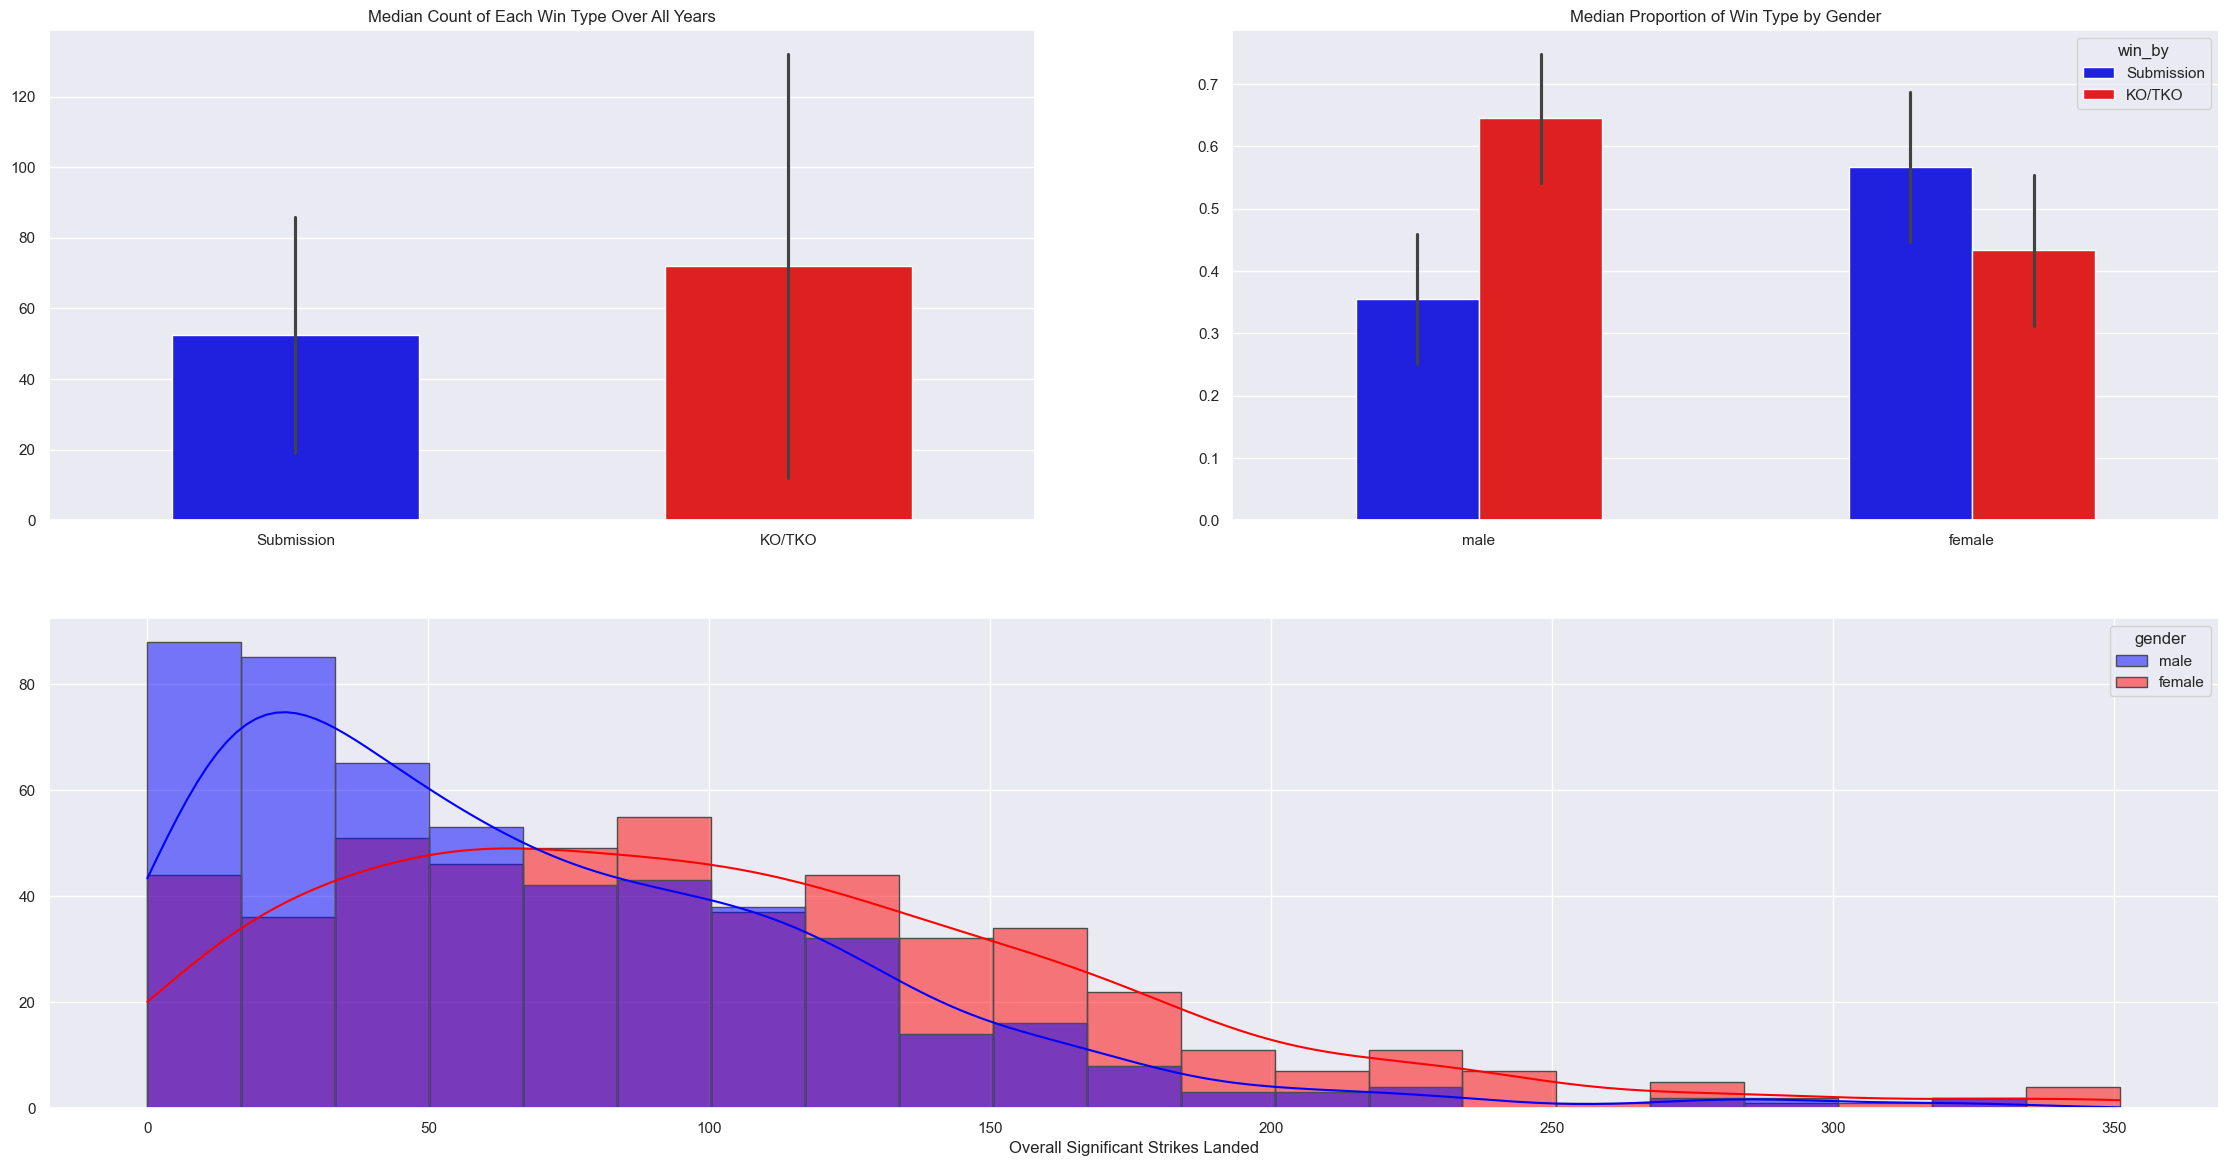

In [21]:
# Create a year column to group by
full_ufc["year"] = full_ufc["date_d"].apply(lambda y: y.year)

# Compare the only two win types directly linked to grappling or striking
filter_win_type = (
    full_ufc[full_ufc["win_by"]
             .isin(["KO/TKO", "Submission", "TKO - Doctor's Stoppage"])]
             .replace("TKO - Doctor's Stoppage", "KO/TKO")
             )

# Count of each win type each year
win_type_count = (
    filter_win_type
    .groupby("year")["win_by"]
    .value_counts()
    .reset_index(name="count")
)

### Win type count figure ###
fig = plt.figure(figsize=(28, 14))

fig.add_subplot(2, 2, 1)   

sns.set_theme(palette=["blue", "red"])

# Median submission and KO wins per year
win_type_ax = sns.barplot(
    data=win_type_count,
    # Vertical bar plot with "win_by" column on x axis
    x="win_by",
    y="count",
    hue="win_by",
    # Use median per year to account for outliers
    estimator=np.median,
    # Add a standard deviation error bar
    errorbar="sd",
    width=0.5
)

plot_params(plot_obj=win_type_ax,
            title="Median Count of Each Win Type Over All Years")

# Proportion of win_type each year by gender
gendered_win_type = (
    filter_win_type
    .groupby(["year", "gender"])["win_by"]
    .value_counts(normalize=True)
    .reset_index(name="count")
    )

### Win type count by gender figure ###
fig.add_subplot(2 ,2, 2)   

# Median Proportion of win_type across all years by gender
div_type_ax = sns.barplot(
    data=gendered_win_type,
    # Vertical bar plot with "gender" column on x axis
    x="gender",
    y="count",
    hue="win_by",
    # Use median proportion per year to account for outliers
    estimator=np.median,
    # Add a standard deviation error bar
    errorbar="sd",
    # Thin bars
    width=0.5
)

plot_params(plot_obj=div_type_ax,
            title="Median Proportion of Win Type by Gender")


### Significant strikes by gender figure ###
fig.add_subplot(2 ,1, 2)

sig_str = full_ufc.copy()

# All significant strikes
sig_str["all_sig_str_lnd"] = (
    sig_str["r_sig_str_lnd"] + sig_str["b_sig_str_lnd"]
    )

# Randomly sample 500 rows from each gender as there are many more male fights
m_sig_str = sig_str[sig_str["gender"] == "male"]

m_sig_str_sample = m_sig_str.sample(n=500)

f_sig_str = sig_str[sig_str["gender"] == "female"]

f_sig_str_sample = f_sig_str.sample(n=500)

# Union the male and female sampled dfs
full_sample = pd.concat([m_sig_str_sample, f_sig_str_sample])

# Histogram of significant strikes by gender
hist_sig_str = sns.histplot(
    full_sample,
    x="all_sig_str_lnd",
    hue="gender",
    # Layers the male and female bars on top of each other
    multiple="layer",
    # Black outline of bars
    edgecolor=".3",
    kde=True
)

plot_params(plot_obj=hist_sig_str,
            x_label="Overall Significant Strikes Landed")

plt.show()

<a id="victory_time"></a>
## Has the Method of Victory Changed Over Time?
Over the years the UFC has had many updates to its rules. These changes have meant that fighters needed to adapt the way they competed. Some key ones were the ban of "Downward pointing of elbow strikes" (also known as 6-12 elbow), "Strikes to the spine or back of the head" and "Throat strikes of any kind" (Department of Law & Public Safety, New Jersey State Athletic Control Board 2002).

<a id="overall"></a>
### Overall Method of Victory Over Time
Prior to 1997, it was anyone's game. Each year, wins by *submission* or *KO/TKO* were similarly likely. In 1997 however, the UFC mandated fighters wear standardised gloves, called boxergenics (Crafted For Champions. Engineered For Excellence. n.d). These gloves are smaller, with less padding than a boxing glove which some fighters were using in their bouts (Crafted For Champions. Engineered For Excellence. n.d). Its not hard to see why striking became more effective with strikers having less padding and grapplers now being forced to wear gloves.

The three other win options were defined in 2001 via the *Unified Rules of Mixed Martial Arts* (Department of Law & Public Safety, New Jersey State Athletic Control Board 2002):
* **Decision - Unanimous**: When all three judges agree on the winning contestant.
* **Decision - Split**: When two of three judges agree on the winning contestant.
* **Decision - Majority**: When two of three judges agree on the winning contestant and the remaining judge considers it a draw.

These unified rules introduced a point system where "Judges shall evaluate mixed martial arts techniques, such as effective striking, effective grappling, control of the fighting area, effective aggressiveness and defense". So instead of aiming for a submission or KO/TKO, there was now a more defined quantifiable way to earn points in a bout, leading to current day fights, where fighters know how to utilise points effectively. Win by unanimous decision had been increasing as a win method since 2005 and from 2010 onwards, it has been the most common way for a fighter to clutch victory in a bout. 


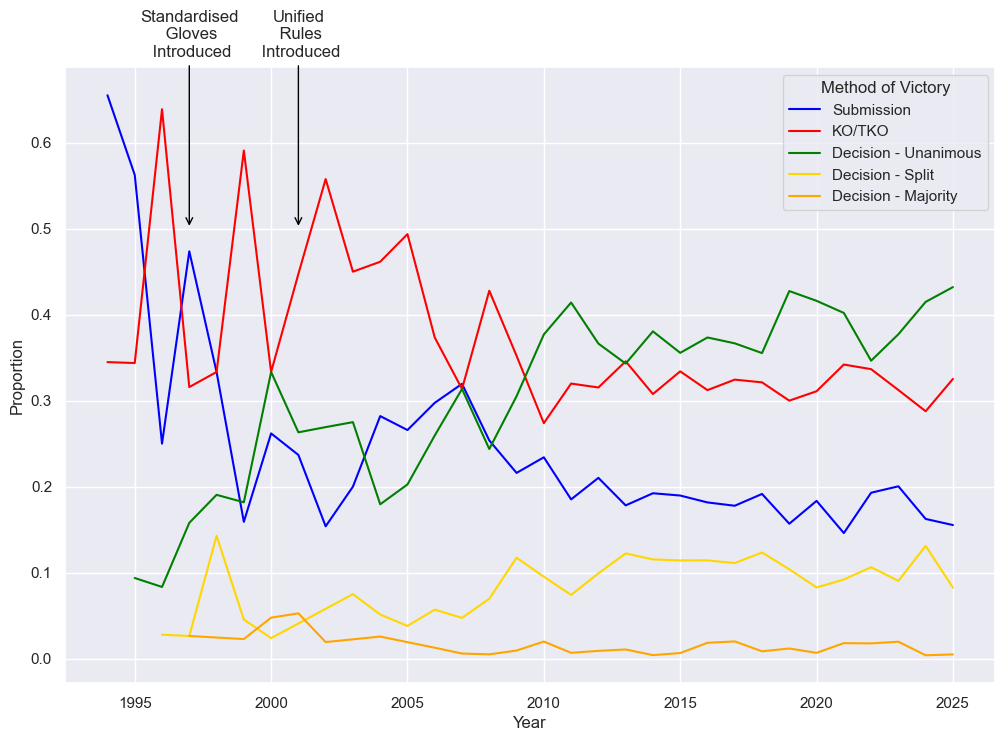

In [22]:
# Filter on the same win types as before but also keep the three "Decision"
# win types 
win_less_filtered = (
    full_ufc[~full_ufc["win_by"]
             .isin(["Other", "Could Not Continue", "DQ", "Overturned"])]
             .replace("TKO - Doctor's Stoppage", "KO/TKO")
             )

# Proportion of each win type per year
win_type_year = (
    win_less_filtered
             .groupby("year")["win_by"]
             .value_counts(normalize=True)
             .reset_index(name="proportion")
             )

### Win types over time figure ###
plt.figure(figsize=(12, 8))

win_year_plt = sns.lineplot(
    data=win_type_year,
    palette=["blue", "red", "green", "gold", "orange"],
    x="year",
    y="proportion",
    hue="win_by"
)

plot_params(plot_obj=win_year_plt,
            x_label="Year",
            y_label="Proportion")


# Create downwards pointing arrow for when the new gloves were introduced
plt.annotate(
    'Standardised\n Gloves\n Introduced',
    xy=(1997, 0.5),
    xytext=(1997, 0.7),
    arrowprops=dict(arrowstyle='->', color='black'),
    # Center the text
    ha="center"
)

# Create downwards pointing arrow for when the unified were introduced
plt.annotate(
    'Unified\n Rules\n Introduced',
    xy=(2001, 0.5),
    xytext=(2001, 0.7),
    arrowprops=dict(arrowstyle='->', color='black'),
    # Center the text
    ha="center"
)

# Change the position and title of the legend 
sns.move_legend(win_year_plt, title="Method of Victory", loc="upper right")

plt.show()

<a id="weight_class"></a>
### Method of Victory Over Time by Weight Class
In the early days of the UFC, two competitors could have large weight differences. In 1997 however, another significant rule change to the UFC was the introduction of two weight classes, heavyweight and lightweight (Bhat 2022). The rules and regulations over the years have affected fighters in different weight classes to varying degrees. 

The heavy hitting heavyweights were completely unaffected by the rule change that prioritised a more points based system, always favouring wins by KO/TKO. On the other hand, the open weight class where fighters of any weight can compete, and middleweights, initially favoured submissions. After introduction of the less padded gloves in 1997 however, placed KOs/TKOs higher. Similarly, lightweights received a spike of KO/TKO wins post 1997, and along with the welterweight class, had a spike in 2001. The spikes in 2001 for the lightweight and welterweight classes could be due to judges under the unified rules "giving the most weight in scoring to effective striking" (Department of Law & Public Safety, New Jersey State Athletic Control Board 2002).

The four lighter weight classes Featherweight, Bantamweight, Flyweight and Strawweight are all consistent since their introduction, with fighters mostly winning via a unanimous decision, displaying the importance of a victory via points in the UFC's later years. The exception of Bantamweight in 2010 however was due to only one fight, won via submission.

Note: Catch is a fight not within the established weight classes. 

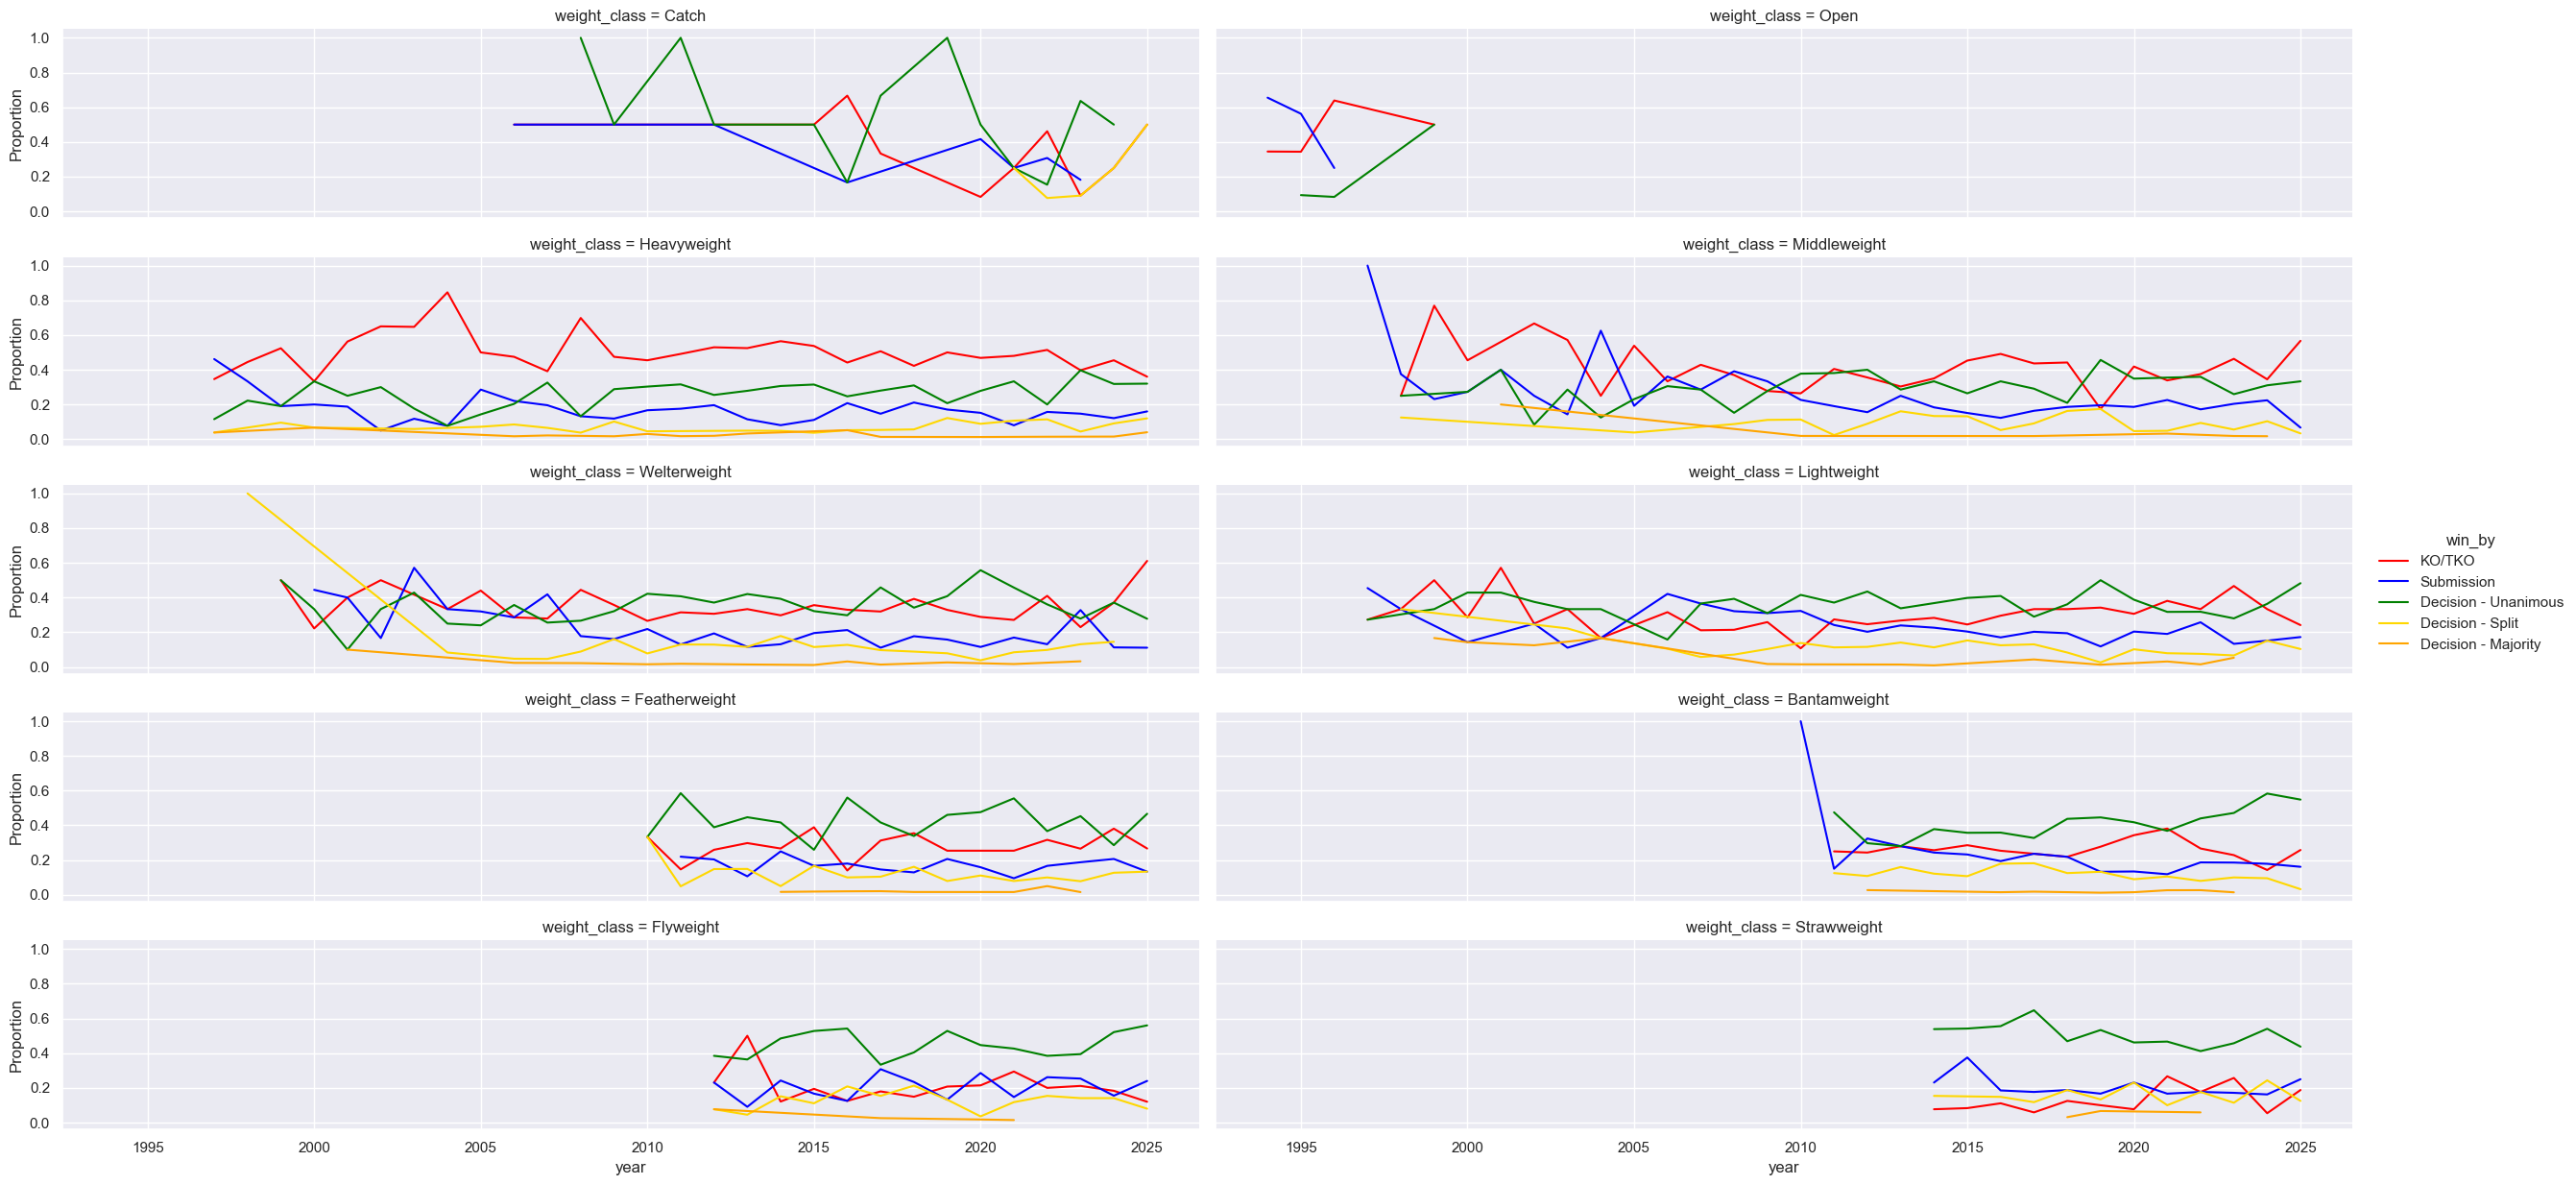

In [23]:
# Proportion of each win type each year by weight class
win_class_year = (
    win_less_filtered
            .groupby(["weight_class", "year"], observed=True)["win_by"]
            .value_counts(normalize=True)
            .reset_index(name="Proportion")
            )

### Win types over time by weight class figure ###
sns.relplot(
    data=win_class_year,
    x="year",
    y="Proportion",
    hue="win_by",
    kind="line",
    # Separate graph for each weight class
    col="weight_class",
    # Custom colours for each win type
    palette=["red", "blue", "green", "gold", "orange"],
    # Splits one column into two
    col_wrap=2,
    # Height of each plot
    height=2.5,
    # Width of each plot
    aspect=5
)

plt.show()

<a id="match_time"></a>
## How does Length Affect the Bout?
The UFC has had a wide variety of match lengths, with differing round numbers and minutes fought in each round.

<a id="overall_dist"></a>
### Overall Distribution
The bulk of time limited matches end approximately between between 5 and 15 minutes, which is likely due to the unified rules introducing a standardised introduced format in 2001 (Department of Law & Public Safety, New Jersey State Athletic Control Board 2002):
* **Non-Championship Contests**: Consist of 3, 5 minute rounds.
* **Championship Contests**: Consist of 5, 5 minute rounds.

Interestingly, most time unlimited matches end approximately between between 2 and 5 minutes. As mentioned previously, matches with no time limit were part of the UFC when it first started. Therefore, the discrepancy is likely due to fighters being unfamiliar with an opponents style, the level of fitness required for a "no holds barred" match (kickboxers, boxers and sumo wrestlers were all on the same fight card) and no breaks between rounds (as there was only one round with no time limit).

The proportion of total minutes fought is negatively skewed, indicating that fighters are more likely than not to go the distance.

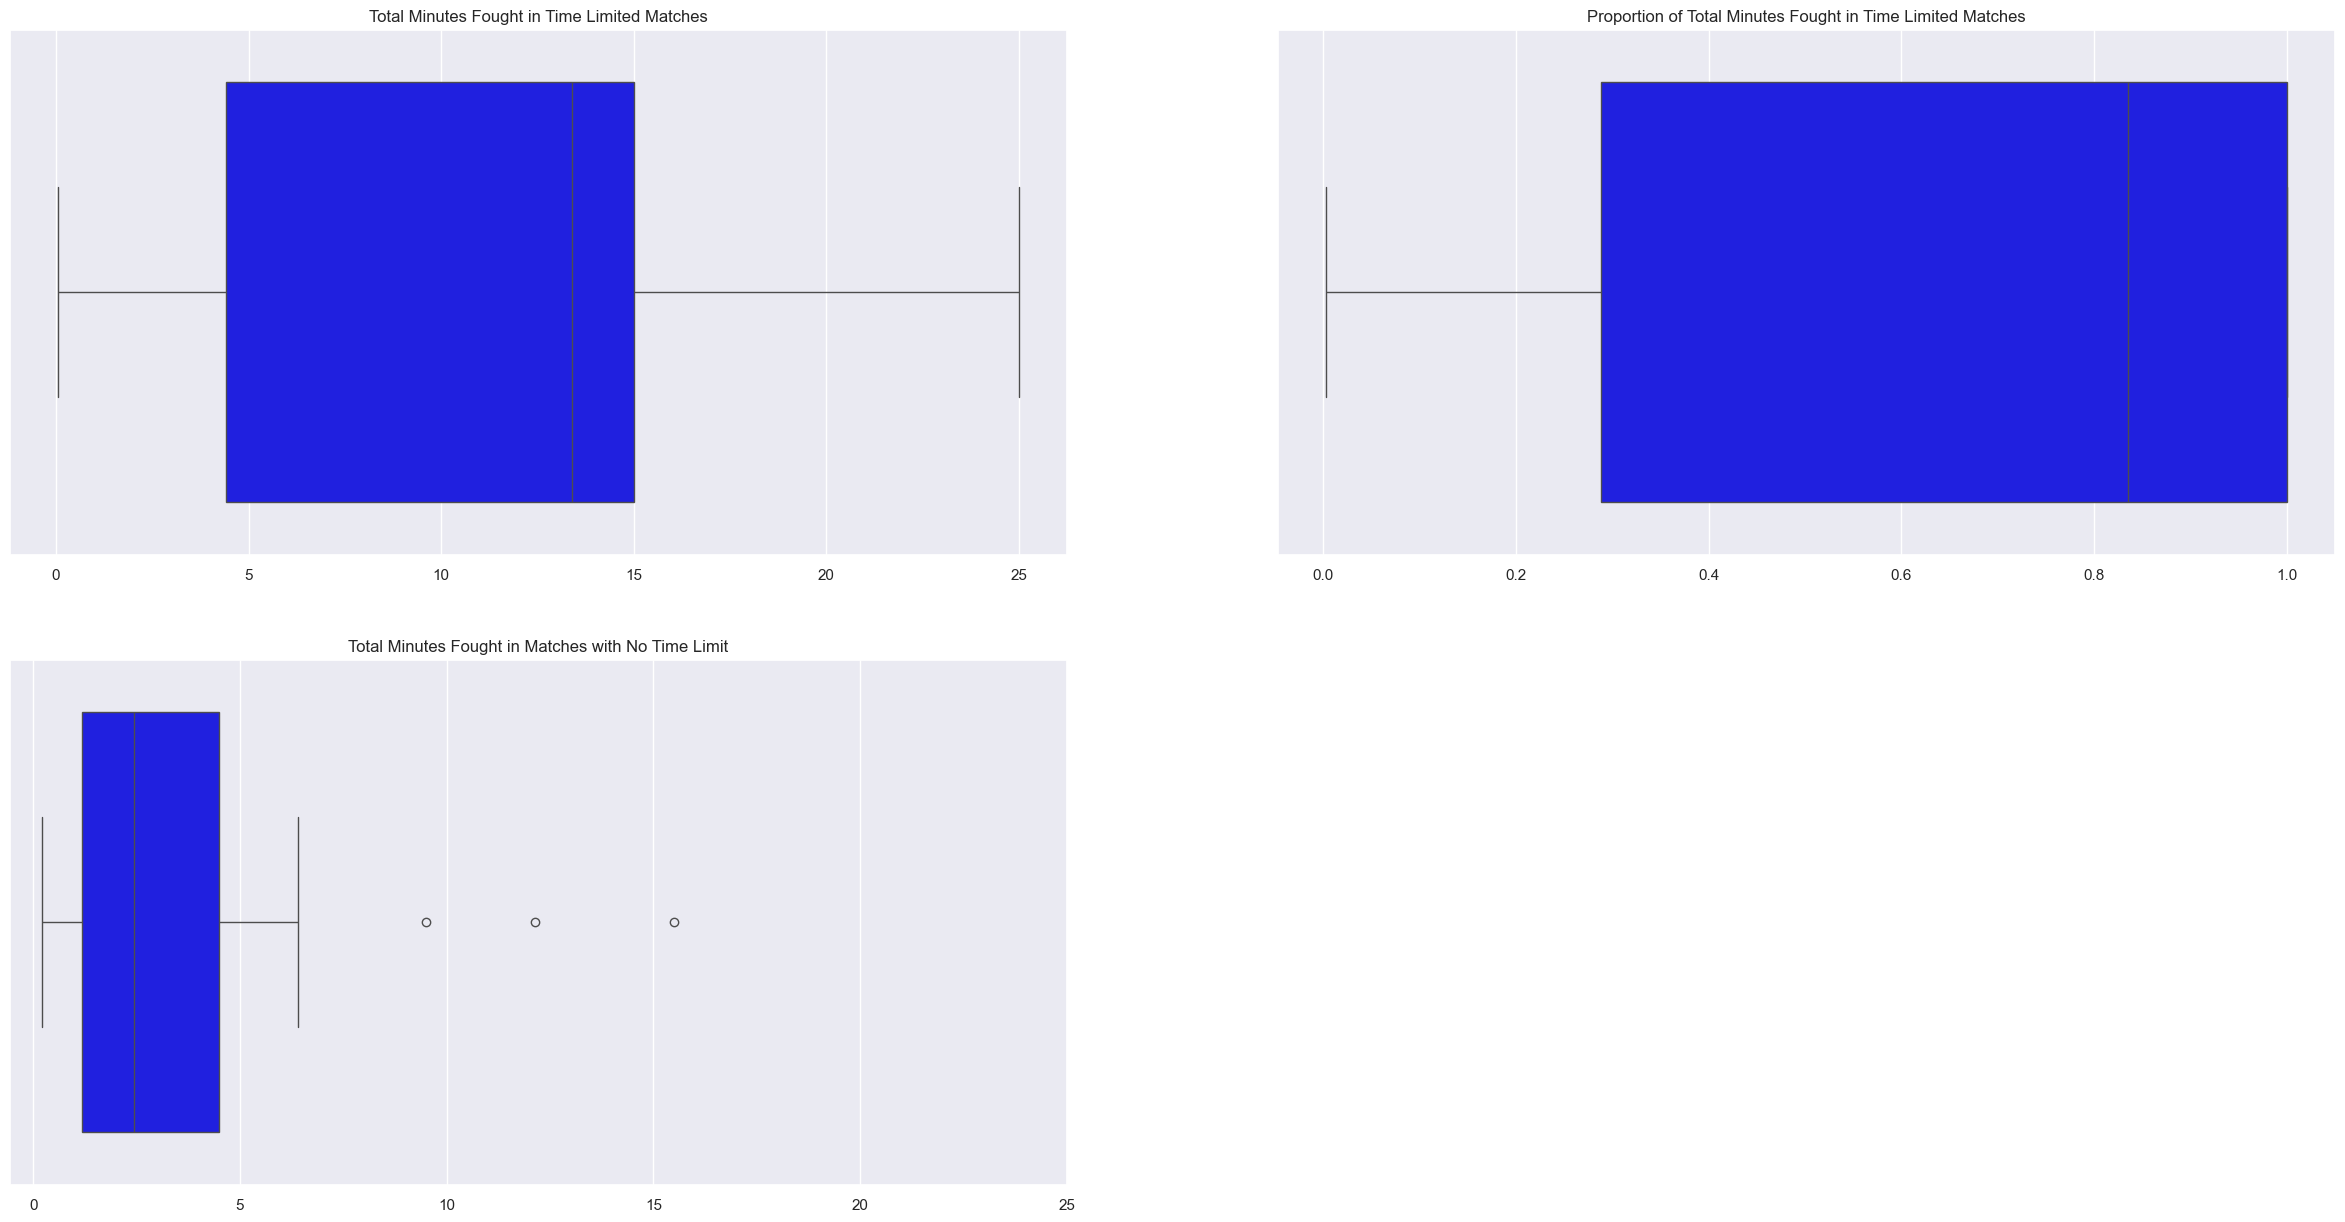

In [24]:
# Select the cols relating to this section of analysis
ufc_time = full_ufc[["w_height_cm",
                     "w_weight_kg",
                     "l_height_cm",
                     "l_weight_kg",
                     "total_round_number",
                     "total_minutes",
                     "last_round",
                     "last_round_time"]]

ufc_time["total_minutes_fought"] = (
    # If "total_minutes" is na (unlimited potential fight time)
    np.where(ufc_time["total_minutes"].isna(),
             # Return "last_round_time" (The length of the one round)
             ufc_time["last_round_time"],
             # Otherwise calculate"total_minutes_fought":
             # total_minutes / total_round_number * (last_round - 1) +
             # last_round_time
             ufc_time["total_minutes"] / ufc_time["total_round_number"] *
             (ufc_time["last_round"] - 1) + ufc_time["last_round_time"])
             )

# Fights with a time limit
limited_time = ufc_time[ufc_time["total_minutes"].notna()]

# Of the total minutes scheduled in a Fight, what proportion was actually
# completed
limited_time["fight_proportion"] = (
    limited_time["total_minutes_fought"] / limited_time["total_minutes"]
    )

# Fights with no time limit
unlimited_time = ufc_time[ufc_time["total_minutes"].isna()]


fig = plt.figure(figsize=(30, 15))

### Total minutes actually fought (limited time) figure ###
fig.add_subplot(2, 2, 1)

limited_time_total = sns.boxplot(
    data=limited_time,
    x="total_minutes_fought")

plot_params(plot_obj=limited_time_total,
            title="Total Minutes Fought in Time Limited Matches")

### Proportion of total minutes fought (limited time) figure ###
fig.add_subplot(2, 2, 2)   

limited_time_prop = sns.boxplot(
    data=limited_time,
    x="fight_proportion")

plot_params(plot_obj=limited_time_prop,
            title="Proportion of Total Minutes Fought in Time Limited Matches")

### Total minutes actually fought (Unlimited time) figure ###
fig.add_subplot(2 ,2, 3)  

limited_time_prop = sns.boxplot(
    data=unlimited_time,
    x="total_minutes_fought")

plot_params(plot_obj=limited_time_prop,
            title="Total Minutes Fought in Matches with No Time Limit",
            xtick_lst=[0, 5, 10, 15, 20, 25])

plt.show()

<a id="bmi"></a>
### Fitness and Going the Distance
Below is the average fighter's BMI vs the proportion of the total fight completed. There are many fights that go the distance with clusters at the top across all BMIs. However, as BMI (representing the fighter's average fitness) increases, the chance of the fight going the distance decreases. The fitter the fighters are, the more they will be able to handle the physical demands of a MMA match, allowing them to stay in relatively good shape throughout the fight.

<Figure size 1200x800 with 0 Axes>

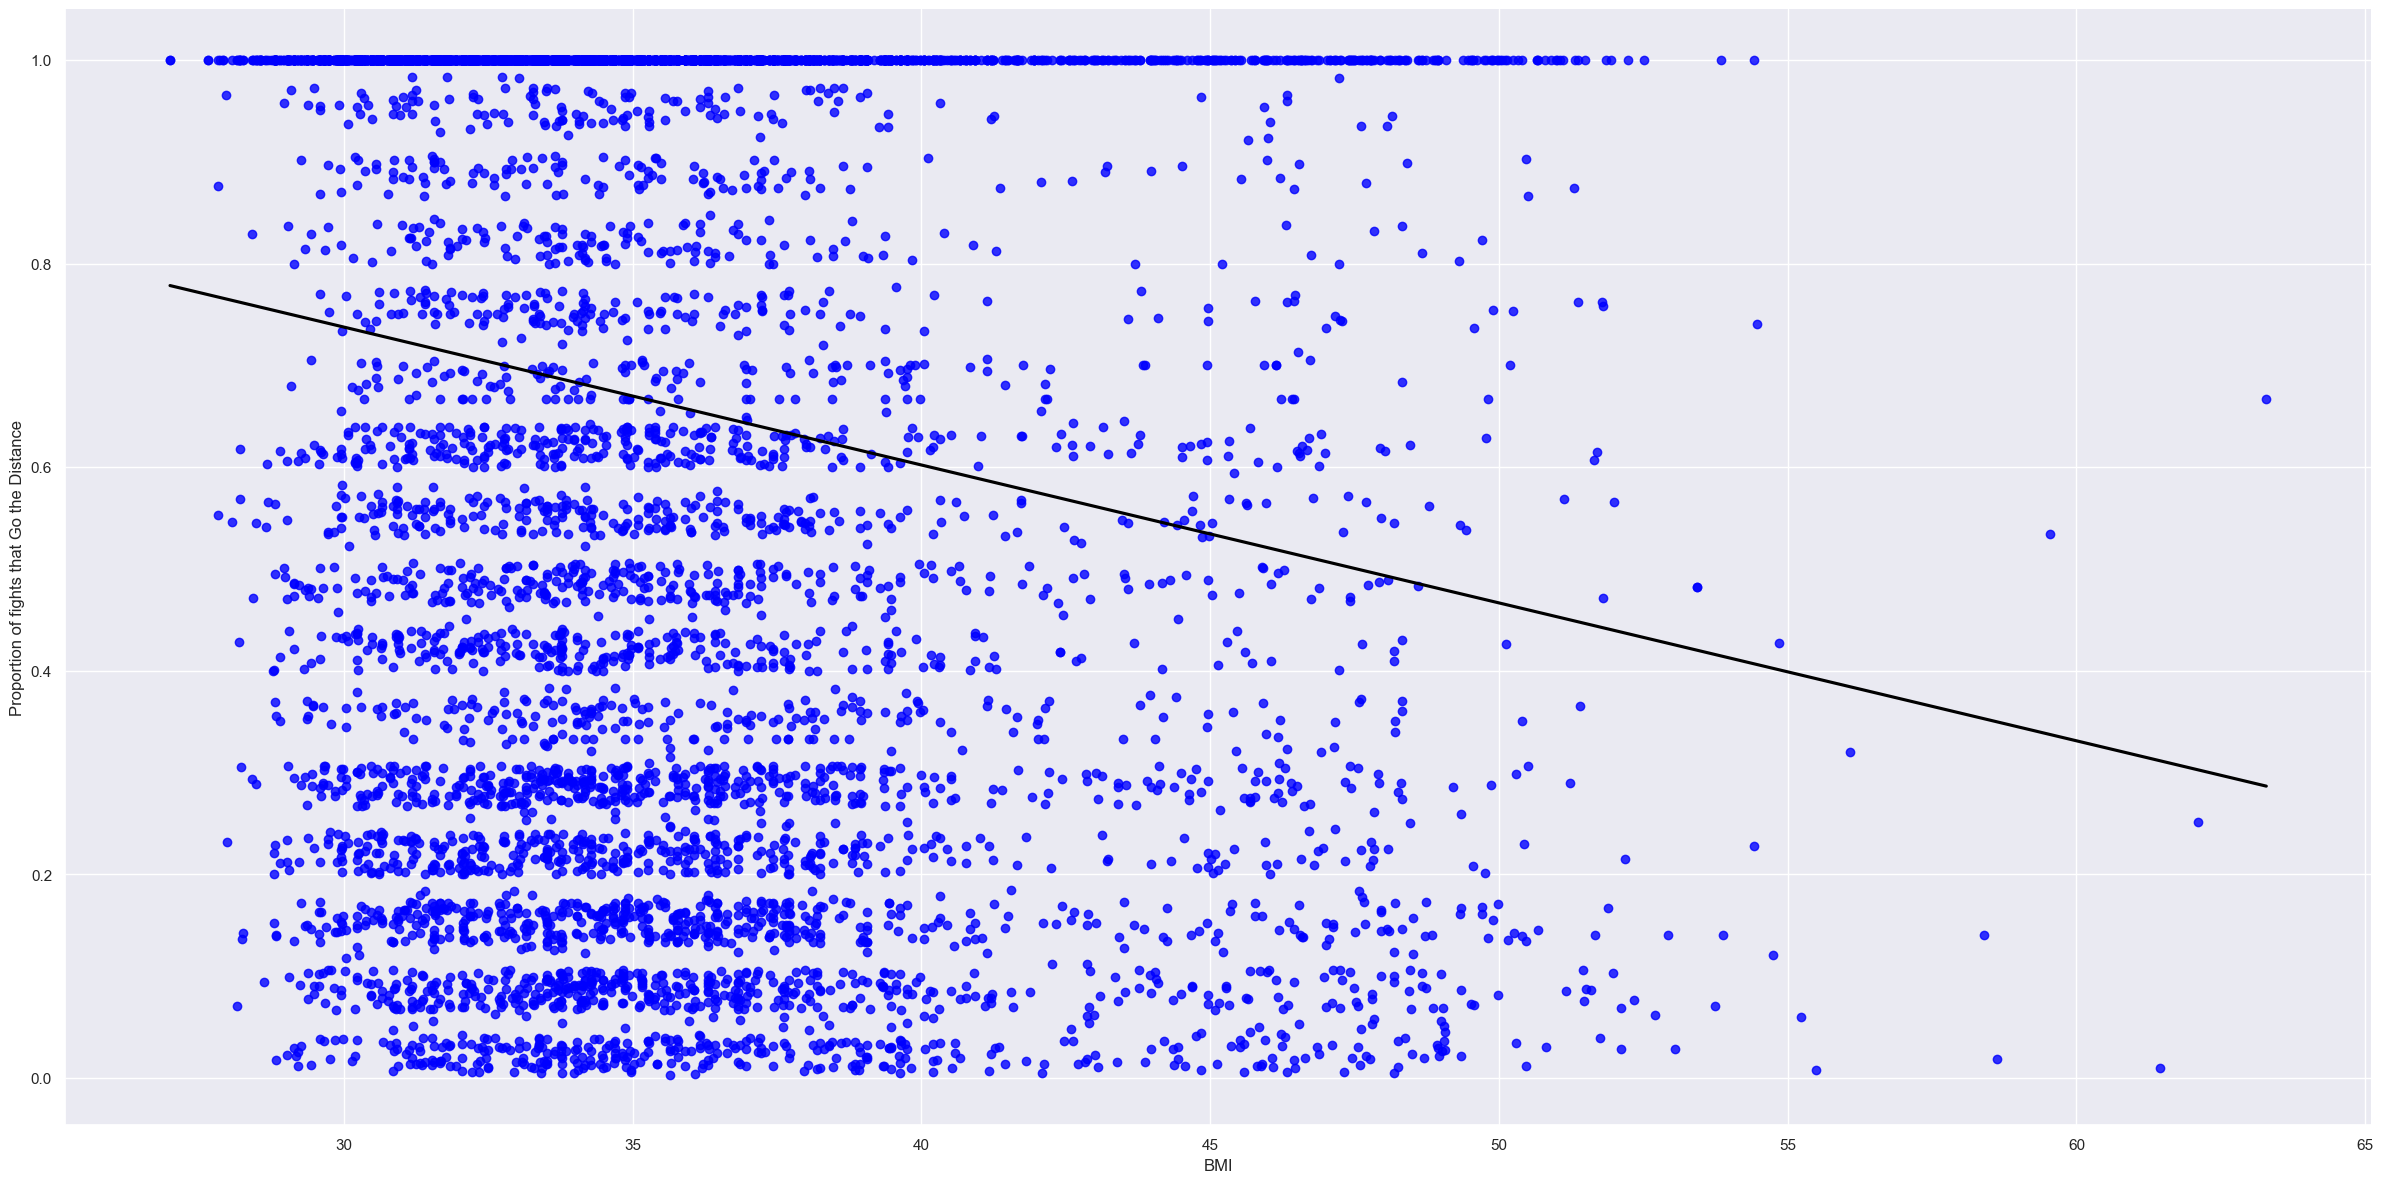

In [25]:
# BMI = weight (kg) / [height (m)]²
limited_time["w_bmi"] = limited_time["w_weight_kg"] / (limited_time["w_height_cm"]/100)**2

limited_time["l_bmi"] = limited_time["l_weight_kg"] / (limited_time["l_height_cm"]/100)**2

# Average BMI between the two fighters
limited_time["bmi_avg"] = limited_time["w_bmi"] + limited_time["l_bmi"] / 2

### Proportion of total minutes to be fought figure ###
plt.figure(figsize=(12, 8))

# Drop NAs to plot regression
limited_time_df = limited_time[["bmi_avg", "fight_proportion"]].dropna()

lm_limited_time = sns.lmplot(
    data=limited_time_df,
    x="bmi_avg",
    y="fight_proportion",
    # No confidence interval
    ci=None,
    # Change aspect ratio
    height=12,
    aspect=2,
    # Black regression line
    line_kws={"color": "black"}
)


plot_params(plot_obj=lm_limited_time,
            x_label="BMI",
            y_label="Proportion of fights that Go the Distance")

<a id="grnd_pnd"></a>
## Who are the Legends of the Ground & Pound Game?
The infamous "Ground & Pound" technique combines the best aspects of grappling and striking, A fighter takes an opponent to the ground and hammers them with powerful top down strikes.

I took main 4 aspects of a great ground & pound fighter and created a "Ground & Pound Score", weighting these aspects in the order they appear below:
* Total wins (as it doesn't matter if a fighter has a great ground & pound game if it can't win fights).
* Proportional wins.
* Percentage of successful takedowns.
* Percentage of successful strikes to a grounded opponent.

There are some familiar names to UFC fans below, Georges St-Pierre, Jon Jones and Anderson Silva are all some of the greats. Jim Miller, a name I was unfamiliar with however, scored as the third best ground and pound fighter. The data actually shows that he has the most wins among all UFC bouts.


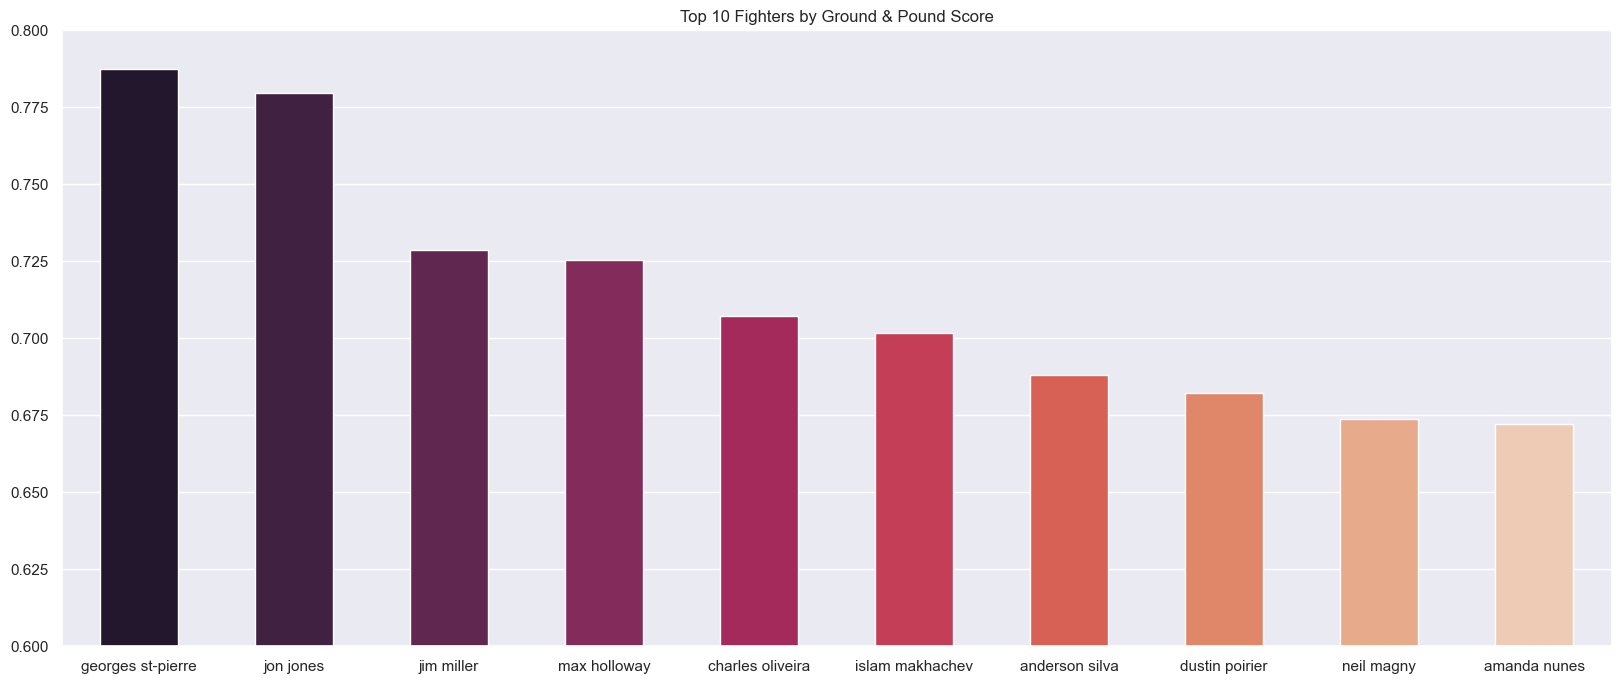

Fighter with the most wins:
         fighter  total_wins  total_losses
1141  jim miller        27.0          19.0


In [26]:
# If the winner is null, it has been assumed that it was a draw so these were 
# removed
no_draws = full_ufc[full_ufc["winner"].notna()]

# If a fighter has null wins or losses then they did not have that information 
# in the fights dataset and thus, it can be assumed they had 0 wins or losses
no_draws["w_total_wins"] = (
    no_draws["w_total_wins"].fillna(0).astype("int64")
    )

no_draws["w_total_losses"] = (
    no_draws["w_total_losses"].fillna(0).astype("int64")
    )

no_draws["l_total_wins"] = (
    no_draws["l_total_wins"].fillna(0).astype("int64")
    )
no_draws["l_total_losses"] = (
    no_draws["l_total_losses"].fillna(0).astype("int64")
    )
# The "no_draws" df contains a mixture of "r_" (red corner), "b_" (blue corner)
# "w_" (winner) and "l_" (loser) characteristics. The "r_" and "b_" are at a
# fight level and the "w_" and "l_" are at the fighter level.

# The below takes any  "r_" and "b_" columns and converts them into "w_" and
# "l_" columns
no_draw_cols = list(no_draws.columns)

for col_name in no_draw_cols:

    if col_name[0:2] == "r_" or col_name[0:2] == "b_":

        # What is between "r_" and "_att" for example
        base_col = col_name[2:-4]
        if col_name[-4:] == "_att":
            
            # Create new winner/loser attempted column names
            win_att_col = "w_" + base_col + "_att"

            loss_att_col = "l_" + base_col + "_att"

            red_att_col = "r_" + base_col + "_att"

            blue_att_col = "b_" + base_col + "_att"

            # Map the "r_"/"_att" and "b_"/"_att" columns to winner ("w_") and
            # loser ("l_") columns
            no_draws[win_att_col] = np.where(
            no_draws["r_fighter"] == no_draws["winner"],
            no_draws[red_att_col],
            no_draws[blue_att_col])

            no_draws[loss_att_col] = np.where(
            no_draws["b_fighter"] == no_draws["loser"],
            no_draws[blue_att_col],
            no_draws[red_att_col])

        elif col_name[-4:] == "_lnd":

            # Create new winner/loser landed column names
            win_lnd_col = "w_" + base_col + "_lnd"

            loss_lnd_col = "l_" + base_col + "_lnd"

            red_lnd_col = "r_" + base_col + "_lnd"

            blue_lnd_col = "b_" + base_col + "_lnd"

            # Map the "r_"/"_lnd",  and "b_"/"_lnd" columns to columns to
            # winner ("w_") and loser ("l_") columns
            no_draws[win_lnd_col] = np.where(
                    no_draws["r_fighter"] == no_draws["winner"],
                    no_draws[red_lnd_col],
                    no_draws[blue_lnd_col])

            no_draws[loss_lnd_col] = np.where(
                    no_draws["b_fighter"]	== no_draws["loser"],
                    no_draws[blue_lnd_col],
                    no_draws[red_lnd_col])
        
        elif col_name[-4:] == "_frac":

            # Create new winner/loser fraction column names
            win_frac_col = "w_" + base_col + "_frac"

            loss_frac_col = "l_" + base_col + "_frac"

            red_frac_col = "r_" + base_col + "_frac"

            blue_frac_col = "b_" + base_col + "_frac"

            # Map the "r_"/"_frac",  and "b_"/"_frac" columns to columns to
            # winner ("w_") and loser ("l_") columns
            no_draws[win_frac_col] = np.where(
                    no_draws["r_fighter"] == no_draws["winner"],
                    no_draws[red_frac_col],
                    no_draws[blue_frac_col])

            no_draws[red_frac_col] = np.where(
                    no_draws["b_fighter"]	== no_draws["loser"],
                    no_draws[blue_frac_col],
                    no_draws[red_frac_col])
            
        else:
            
            # For columns without a suffix
            base_col = col_name[2:]
            

            # Create new winner/loser fraction column names
            win_col = "w_" + base_col

            loss_col = "l_" + base_col

            red_col = "r_" + base_col

            blue_col = "b_" + base_col

            # Map the remaining columns to winner ("w_") and loser ("l_") columns
            no_draws[win_col] = np.where(
                    no_draws["r_fighter"] == no_draws["winner"],
                    no_draws[red_col],
                    no_draws[blue_col])

            no_draws[loss_col] = np.where(
                    no_draws["b_fighter"]	== no_draws["loser"],
                    no_draws[blue_col],
                    no_draws[red_col])

# Union the winner and loser columns and merge the columns of interest together
fighter_level_df = pd.concat([
    pd.concat([no_draws["winner"], no_draws["loser"]],
              ignore_index=True),
    pd.concat([no_draws["w_ground_att"], no_draws["l_ground_att"]],
              ignore_index=True),
    pd.concat([no_draws["w_ground_lnd"], no_draws["l_ground_lnd"]],
              ignore_index=True),
    pd.concat([no_draws["w_td_acc_frac"], no_draws["l_td_acc_frac"]],
              ignore_index=True),
    pd.concat([no_draws["w_total_wins"], no_draws["l_total_wins"]],
              ignore_index=True),
    pd.concat([no_draws["w_total_losses"], no_draws["l_total_losses"]],
              ignore_index=True) 
              
    ], axis=1)

# Rename new cols in df
fighter_level_df.columns = ["fighter",
                            "ground_att",
                            "ground_lnd",
                            "td_acc_frac",
                            "total_wins",
                            "total_losses"]

# The fighter_level_df has every winner and loser of a fight stacked on top of
# each other, along with their stats. This means there are many duplicates so
# we group by the fighter and take the mean of each column (the td_acc_frac,
# total_losses, and total_wins are the same for each fighter so
# this is really to find the mean of ground_att and ground_lnd).      
fighter_gnp = (
    fighter_level_df
    .groupby("fighter")
    .agg({
        "ground_att": "mean",
        "ground_lnd": "mean",
        "td_acc_frac": "mean",
        "total_wins": "mean",
        "total_losses": "mean"
    }).reset_index()
)

# Now that we have a df at the fighter level with the columns of interest, we
# can create new columns
fighter_gnp["ground_frac"] = (
    fighter_gnp["ground_lnd"] / fighter_gnp["ground_att"]
    ).fillna(0)

# Calculate win proportions out of total matches
fighter_gnp["win_proportion"] = (
    fighter_gnp["total_wins"] / 
    (fighter_gnp["total_wins"] + fighter_gnp["total_losses"])
    )

# Normalise total wins to ensure it can equally contribute to the ground and 
# pound score (gnp score)
scaler = MinMaxScaler()

fighter_gnp["total_wins_norm"] = scaler.fit_transform(fighter_gnp[["total_wins"]])


fighter_gnp["gnp_score"] = (
    0.40 * fighter_gnp["total_wins_norm"] +
    0.30 * fighter_gnp["win_proportion"] +
    0.20 * fighter_gnp["td_acc_frac"] +
    0.10 * fighter_gnp["ground_frac"]
    )

### Top 10 ground and pound fighters figure ###
plt.figure(figsize=(20, 8))

top10_gnp = fighter_gnp.sort_values(by=["gnp_score"], ascending=False).head(10)

top10_gnp_plt = sns.barplot(
    data=top10_gnp,
    # Vertical bar plot with "gender" column on x axis
    x="fighter",
    y="gnp_score",
    # Thin bars
    width=0.5,
    palette="rocket"
)
plot_params(plot_obj=top10_gnp_plt,
            title="Top 10 Fighters by Ground & Pound Score",
            ylim_lst=[0.6, 0.8])

plt.show()

print("Fighter with the most wins:")
print(
    fighter_gnp
    .sort_values(by=["total_wins"], ascending=False)
    .head(1)[["fighter", "total_wins", "total_losses"]]
    )

<a id="champion"></a>
## What Makes a Champion? The Characteristics of a Successful Fighter
Other than a competitor's fight statistics such as takedowns or strikes, other physical attributes definitely play a part in a making a champion.

The favoured fighter of a bout is usually placed in the red corner (Bradley Jr 2024). I have used this to create a new column as the target variable in a logistic regression. This column identifies whether the red corner ("r_fighter") was the winner of the bout. As shown in the regression below, age, height and reach all play a part the probability of a fighter winning. As expected, the taller the fighter, and greater their reach, the more likely they are to be securing wins. These have similar effects on the probability of winning. Age however, has the opposite effect with older fighters gaining less victories. Additionally, the effect of age on winning is much stronger with a steeper curve.

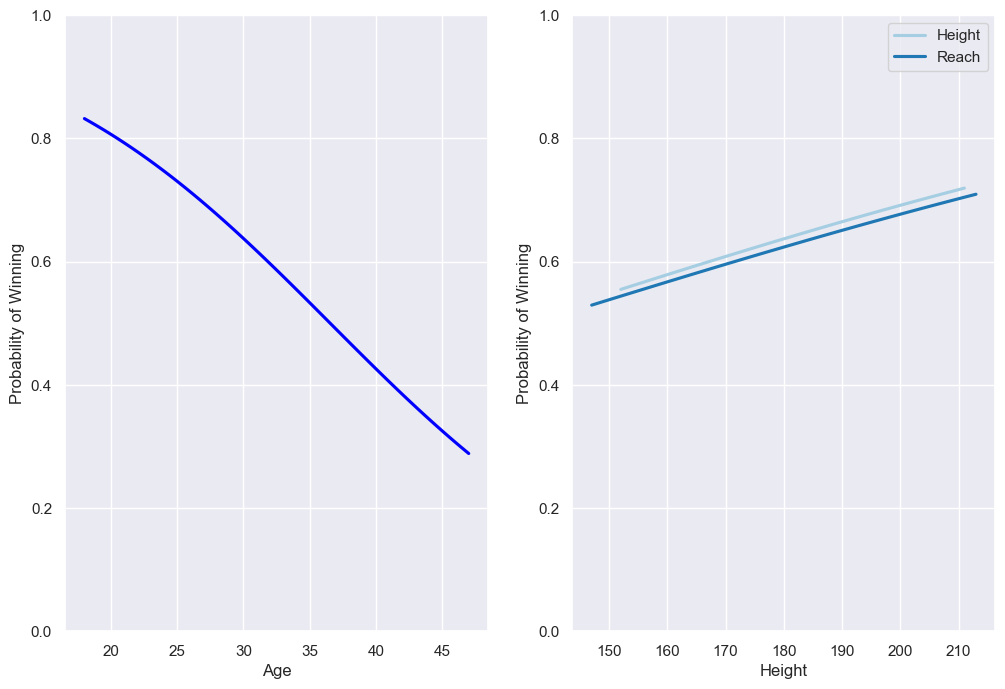

In [27]:
# Create the binary target variable
full_ufc["r_win"] = np.where(full_ufc["r_fighter"] == full_ufc["winner"], 1, 0)


full_ufc["r_age"] = (
    # Calculate the age of the red corner fighter at time of fight
    # (using a row wise calculation)
    full_ufc.apply(
        # Difference between fight date and winner's date of birth
        lambda row: calc_age(row["w_dob_d"], row["date_d"])
        # If the red corner was the winner
        if row["r_fighter"] == row["winner"]
        # Otherwise return difference between fight date and loser's
        # date of birth
        else calc_age(row["l_dob_d"], row["date_d"]), axis=1)
)
ufc_copy = full_ufc.copy()

# If the red corner fighter was the winner
ufc_copy["r_height"] = np.where(ufc_copy["r_fighter"] == ufc_copy["winner"],
                              # Return the winner's height
                              ufc_copy["w_height_cm"],
                              # Otherwise return the loser's height
                              ufc_copy["l_height_cm"])

# If the red corner fighter was the winner
ufc_copy["r_reach"] = np.where(ufc_copy["r_fighter"] == ufc_copy["winner"],
                              # Return the winner's reach
                              ufc_copy["w_reach_cm"],
                              # Otherwise return the loser's reach
                              ufc_copy["l_reach_cm"])

# Drop NAs to plot regression
lm_plot = ufc_copy[["r_age", "r_height", "r_reach", "r_win"]].dropna()


fig = plt.figure(figsize=(12, 8))

### Age on wins by red corner ###
fig.add_subplot(1 ,2, 1)

sns.set_theme(palette="Paired")

age_lm_plot = sns.regplot(
    data=lm_plot,
    x="r_age",
    y="r_win",
    label="Age",
    # No confidence interval
    ci=None,
    # Points on the Scatter plot are grouped at 0 and 1 due to the nature of a
    # logistic regression so there is no need to display them
    logistic=True,
    scatter=False
)

plot_params(plot_obj=age_lm_plot,
            y_label="Probability of Winning",
            x_label="Age",
            ylim_lst=[0, 1])

### Height and reach on wins by red corner ###
fig.add_subplot(1 ,2, 2)

sns.regplot(
    data=lm_plot,
    x="r_height",
    y="r_win",
    label="Height",
    # No confidence interval
    ci=None,
    # Points on the Scatter plot are grouped at 0 and 1 due to the nature of a
    # logistic regression so there is no need to display them
    logistic=True,
    scatter=False
)
# Assign plot to variable to rename labels
reach_lm_plot = sns.regplot(
    data=lm_plot,
    x="r_reach",
    y="r_win",
    label="Reach",
    # No confidence interval
    ci=None,
    # Points on the Scatter plot are grouped at 0 and 1 due to the nature of a
    # logistic regression so there is no need to display them
    logistic=True,
    scatter=False
)


plot_params(plot_obj=reach_lm_plot,
            y_label="Probability of Winning",
            x_label="Height",
            ylim_lst=[0, 1],
            legend=True)

plt.show()

<a id="goat"></a>
## Who are The Greatest of All Time (GOAT)
There is some crossover here with the results of the ground and pound section, with some fighters showing up in both results (Georges St-Pierre, Jon Jones and Jim Miller, for example). The "Champion" score, compared to the "Ground & Pound" score puts more weight towards the proportion of wins instead of just total wins. I thought I'd also graph the fighter's average successful takedowns, which was not a part of calculating the score and yet, its clear that a fighter is winning more with more successful takedowns. The below indicates that as champion score increases, so does a fighter's successful takedowns. 

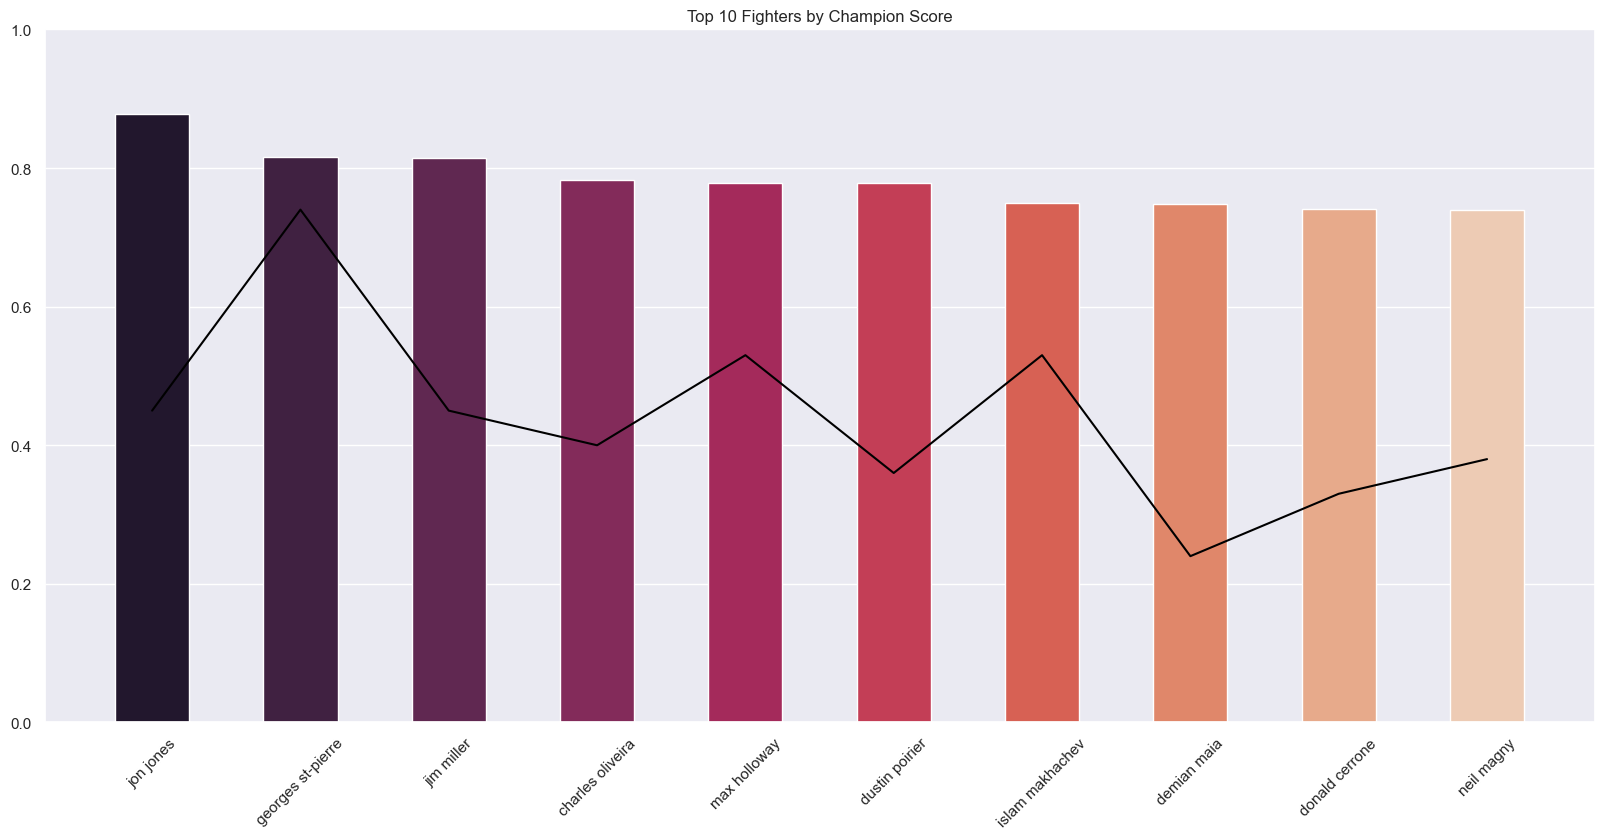

In [28]:
# The gnp data will be used differently below
champion_agg = fighter_gnp.copy()

champion_agg["champion_score"] = (
    0.55 * champion_agg["total_wins_norm"] +
    0.45 * champion_agg["win_proportion"]
    )

### Top 10 champion fighters figure ###
plt.figure(figsize=(20, 9))

top10_champions = (
    champion_agg.sort_values(by=["champion_score"], ascending=False).head(10)
    )

# Assign a variable to apply limits and a label
champion_plt = sns.barplot(
    data=top10_champions,
    # Vertical bar plot with "gender" column on x axis
    x="fighter",
    y="champion_score",
    # Thin bars
    width=0.5,
    palette="rocket"
)

sns.lineplot(
    data=top10_champions,
    # Vertical bar plot with "gender" column on x axis
    x="fighter",
    y="td_acc_frac",
    c="black"
)

plot_params(plot_obj=champion_plt,
            title="Top 10 Fighters by Champion Score",
            ylim_lst=[0, 1])

champion_plt.tick_params(axis='x', rotation=45)

plt.show()



<a id="conclusion"></a>
## Conclusion
The UFC has captivated audiences since its first introduction. It has exploded in popularity, with an increasing number of martial artists aiming to enter the octagon. To those with such ambitions, I have a few things to say.

To my fellow Brazilian Jui-Jitsu practitioners, unless you're fighting in the women's division, focus on your striking game. Over time fighters in the UFC have shifted from dominating with submissions, to dominating with strikes.

Learn the points system. As much as a knockout or a well timed submission is the fan favorite way to end a match, consistent wins in modern day UFC fights will be achieved by unanimous decision, with all judges in agreeance on a winner.

Although most UFC matches are 3, 5 minute rounds, championship bout are longer with 5, 5 minute rounds. If you ever find yourself in this situation (and if you, do I doubt you'd need to listen to my advice), or any lengthy matches, prioritise aerobic fitness. As much as getting physically stronger is great for knockouts and grappling, outlasting an opponent will ensure the fight doesn't end early.

If you are a relatively older or shorter fighter, the data shows that you're less likely to grasp victory in matches. To counteract this, uplift your takedown/ground and pound game. All the greats over the years have had these two skills in abundance. 

<a id="ref"></a>
## References
* Rajeev Warrier 2022, *GitHub*, accessed 4 June 2025<br><https://github.com/WarrierRajeev/UFC-Predictions>.
* History of the UFC n.d., accessed 9 June 2025, <https://www.ufc.com/history-ufc>.
* Pattle, A. 2023, '‘The only rules? No biting and no eye-gouging’: UFC’s first champion Royce Gracie on the night MMA was born', *The Independent*, 10 February, originally published 2019, accessed 9 June 2025.
* Raimondi, M. 2023, 'Examining UFC's future after 30 years of fights', *ESPN*, 13 November, accessed 9 June 2025.
* Bradley Jr, T. 2024, 'Timothy Bradley Jr.'s 10 things to look for when watching a boxing match', *ESPN*, 13 November, accessed 13 June 2025.
* Events & Fights n.d, accessed 14 June 2025, <http://ufcstats.com/statistics/events/completed>.
* Fighters n.d, accessed 14 June 2025, <http://ufcstats.com/statistics/fighters>.
* Crafted For Champions. Engineered For Excellence. n.d, ,INTRODUCING UFC OFFICIAL FIGHT GLOVE 5EIGHT CHAMPION & 3EIGHT, accessed 14 June 2025, <https://www.ufc.com/authentic-fight-glove>.
* Department of Law & Public Safety, New Jersey State Athletic Control Board 2002, Mixed Martial Arts Unified Rules of Conduct.
* Bhat, V. 2022, 'When did UFC start weight classes?', *SportsKeeda*, 10 February, accessed 14 June 2025.